In [1]:
# ── Portable environment bootstrap · local ↔ Kaggle ──────────────────────────
# No-op on my machine (the notebook already runs from notebooks/, so ../data and
# ../reports resolve). On Kaggle it rebuilds that layout: it finds the cleaned
# dataset file whatever its name/compression (Kaggle may rename or extract it),
# detects the real format from the file's magic bytes, and materialises it at
# ../data/processed/df_clean.csv — so every relative path below keeps working.
import os, glob, gzip, zipfile, shutil
from pathlib import Path

if Path('/kaggle/input').exists():
    work   = Path('/kaggle/working')
    nb_dir = work / 'notebooks'
    nb_dir.mkdir(exist_ok=True)
    os.chdir(nb_dir)                                   # now '..' == /kaggle/working
    proc = work / 'data' / 'processed'
    proc.mkdir(parents=True, exist_ok=True)
    (work / 'reports' / 'figures').mkdir(parents=True, exist_ok=True)

    target = proc / 'df_clean.csv'
    if not target.exists():
        cands = [c for c in glob.glob('/kaggle/input/**/df_clean*', recursive=True)
                 if os.path.isfile(c)]
        if not cands:
            raise FileNotFoundError(
                "No df_clean.* file in the attached dataset — attach the Cyclistic dataset.")
        # prefer a real .csv, else the largest candidate
        csvs = [c for c in cands if c.lower().endswith('.csv')]
        src  = csvs[0] if csvs else max(cands, key=os.path.getsize)

        with open(src, 'rb') as f:
            magic = f.read(2)
        if magic == b'\x1f\x8b':                       # gzip
            with gzip.open(src, 'rb') as fi, open(target, 'wb') as fo:
                shutil.copyfileobj(fi, fo)
        elif magic == b'PK':                            # real zip archive
            with zipfile.ZipFile(src) as z:
                inner = [n for n in z.namelist() if n.lower().endswith('.csv')] or z.namelist()
                with z.open(inner[0]) as fi, open(target, 'wb') as fo:
                    shutil.copyfileobj(fi, fo)
        else:                                           # already plain-text CSV
            os.symlink(src, target)
        print(f"Kaggle detected — df_clean.csv ready (from {os.path.basename(src)})")
    else:
        print("Kaggle detected — df_clean.csv already present.")
else:
    print("Local environment — using the existing ../data and ../reports layout.")


Local environment — using the existing ../data and ../reports layout.


# Indice <a id='toc'></a>

- [Setup e Caricamento Dati](#setup)
- [Feature Engineering](#features)
- [1. Panoramica: Member vs Casual](#overview)
- [2. Analisi Temporale](#temporal)
  - [2.1 Pattern Intragiornalieri (Orario)](#hourly)
  - [2.2 Pattern Stagionali (Mensile)](#monthly)
- [3. Analisi Spaziale: Zoning Districts di Chicago](#spatial)
  - [3.1 Caricamento Dati e Spatial Join](#join)
  - [3.2 Validazione Statistica — Test Chi-Quadro](#chi2)
  - [3.3 Distribuzione per Zona: Member vs Casual](#zones)
  - [3.4 Pattern Viaggio Zona-Zona](#heatmaps)
  - [3.5 Analisi della Divergenza](#divergence)
  - [3.6 Mappa Conversione](#conversion)
- [4. Conclusioni e Raccomandazioni](#conclusions)
- [5. Salvataggio Output](#saving)

---
# Setup e Caricamento Dati <a id='setup'></a>
[↑ back to top](#toc)

**Input:** `df_clean.csv` — il dataset pulito prodotto da `01_data_cleaning.ipynb`.  
Contiene ~5.8 milioni di viaggi da aprile 2025 a marzo 2026, suddivisi per
tipologia utente (member / casual) e tipo di bici (classic, electric, scooter).

In [2]:
import os
import time
import copy
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import geopandas as gpd
from shapely import wkt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MultipleLocator, FuncFormatter
from numba import jit, njit
from scipy.stats import chi2_contingency

try:
    import holidays as hol
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'holidays', '-q'])
    import holidays as hol

In [3]:
subfolder = '../data/processed'
filename  = 'df_clean.csv'
path      = os.path.join(subfolder, filename)

df_clean = pd.read_csv(path)
print(f"Dataset caricato — {len(df_clean):,} righe, {len(df_clean.columns)} colonne")
print(f"Colonne: {df_clean.columns.tolist()}")

Dataset caricato — 5,841,925 righe, 13 colonne
Colonne: ['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']


---
# Feature Engineering <a id='features'></a>
[↑ back to top](#toc)

Prima di iniziare l'analisi aggiungo tre colonne derivate:
1. **`trip_duration`** — durata del viaggio in minuti (con cap a 1 min – 24h per escludere outlier).
2. **`day_category`** — classifica ogni giorno come `weekday`, `weekend` o `holiday` (festivi Illinois).
3. **`ride_date`** — data normalizzata della partenza, usata per il conteggio dei giorni unici.

In [4]:
df_clean['started_at'] = pd.to_datetime(df_clean['started_at'])
df_clean['ended_at']   = pd.to_datetime(df_clean['ended_at'])

In [5]:
# Backup before filtering outliers
df_original = df_clean.copy()

# Calculate duration in minutes
duration = ((df_clean['ended_at'] - df_clean['started_at']).dt.total_seconds() / 60).round(2)

# Filter: keep trips between 1 minute and 24 hours (1 440 min)
df_clean = df_clean[(duration > 1) & (duration < 1440)].copy()
df_clean['trip_duration'] = ((df_clean['ended_at'] - df_clean['started_at'])
                              .dt.total_seconds() / 60).round(2)

print(f"From {len(df_original):,} to {len(df_clean):,} rows "
      f"({(1 - len(df_clean)/len(df_original))*100:.2f}% removed as duration outliers)")
print(f"trip_duration — min: {df_clean['trip_duration'].min():.1f} min  "
      f"max: {df_clean['trip_duration'].max():.1f} min  "
      f"median: {df_clean['trip_duration'].median():.1f} min")

From 5,841,925 to 5,680,076 rows (2.77% removed as duration outliers)
trip_duration — min: 1.0 min  max: 1440.0 min  median: 9.7 min


### Categoria giornaliera: weekday / weekend / holiday

Uso la libreria `holidays` per identificare i festivi dell'Illinois e classifico
ogni viaggio in una delle tre categorie con un approccio vettorizzato (nessun iterrow).

[↑ back to top](#toc)

In [6]:
start_date = pd.to_datetime(df_clean['started_at']).min().normalize().date()
end_date   = pd.to_datetime(df_clean['started_at']).max().normalize().date()

us_holidays  = hol.US(state='IL', years=[start_date.year, end_date.year])
holiday_set  = {h for h in us_holidays if start_date <= h <= end_date}
holiday_dates = pd.to_datetime(sorted(holiday_set))

print(f"Date range       : {start_date} → {end_date}")
print(f"Illinois holidays in range : {len(holiday_set)}")

Date range       : 2025-06-01 → 2026-05-31
Illinois holidays in range : 13


In [7]:
df_clean['started_at'] = pd.to_datetime(df_clean['started_at'])
df_clean['date_only']  = df_clean['started_at'].dt.date
df_clean['is_holiday'] = df_clean['date_only'].isin(holiday_set)

df_clean['day_category'] = np.where(
    df_clean['is_holiday'], 'holiday',
    np.where(df_clean['started_at'].dt.dayofweek < 5, 'weekday', 'weekend')
)

df_clean.drop(columns=['date_only', 'is_holiday'], inplace=True)

print("Distribuzione categorie giornaliere:")
print(df_clean['day_category'].value_counts().to_string())

Distribuzione categorie giornaliere:
day_category
weekday    3892628
weekend    1621331
holiday     166117


Le tre categorie separano contesti comportamentali distinti:  
- **Weekday** — dominato probabilmente dai pendolari (member).  
- **Weekend + Holiday** — dominato probabilmente da corse leisure (casual).  

La sezione 1 verificherà questa ipotesi a livello macro.

[↑ back to top](#toc)

---
# 1. Panoramica: Member vs Casual <a id='overview'></a>
[↑ back to top](#toc)

Prima di entrare nei dettagli temporali e spaziali, voglio capire a grandi linee
come si distribuisce l'utilizzo tra le due tipologie di utente nei giorni feriali
rispetto ai fine settimana/festivi.

Un'asimmetria netta è il primo segnale che i due gruppi hanno abitudini d'uso
strutturalmente diverse — commuting vs. tempo libero.

In [8]:
import time
t0 = time.time()

df_clean = df_clean.copy()
df_clean['started_at'] = pd.to_datetime(df_clean['started_at'], format='mixed')
df_clean['ended_at']   = pd.to_datetime(df_clean['ended_at'],   format='mixed')
df_clean = df_clean.drop(columns=['date_only'], errors='ignore')
df_clean['ride_date']  = df_clean['started_at'].dt.normalize()

# Distribuzione % per tipologia utente e tipo di giorno
seg = (
    df_clean
    .assign(day_simple=df_clean['day_category'].map(lambda x: 'weekday' if x == 'weekday' else 'weekend/holiday'))
    .groupby(['member_casual', 'day_simple'])
    .size()
    .rename('rides')
)
pct = (seg / seg.groupby(level=0).transform('sum') * 100).round(1).rename('pct')
summary = pd.concat([seg, pct], axis=1)

print("Split weekday / weekend per tipologia utente:")
print(summary.to_string())
print(f"\n→ ride_date creata | range: {df_clean['ride_date'].min().date()} — {df_clean['ride_date'].max().date()} ({df_clean['ride_date'].nunique()} giorni unici)")
print(f"  completato in {time.time()-t0:.2f}s")

Split weekday / weekend per tipologia utente:
                                 rides   pct
member_casual day_simple                    
casual        weekday          1183160  58.8
              weekend/holiday   829349  41.2
member        weekday          2709468  73.9
              weekend/holiday   958099  26.1

→ ride_date creata | range: 2025-06-01 — 2026-05-31 (365 giorni unici)
  completato in 2.30s


---
# 2. Analisi Temporale <a id='temporal'></a>
[↑ back to top](#toc)

La panoramica iniziale ha mostrato come member e casual si distribuiscano diversamente
tra giorni feriali e festivi. Qui voglio scendere nel dettaglio: **quando** durante la
giornata e **in quali mesi** i due gruppi utilizzano il servizio in modo più divergente.

## 2.1 Pattern Intragiornalieri (Orario) <a id='hourly'></a>
[↑ back to top](#toc)

Mi aspetto che i member mostrino doppi picchi negli orari di pendolarismo (8:00 e 17-18:00),
mentre i casual dovrebbero concentrarsi nelle ore centrali del pomeriggio — coerente con
un uso leisure.

La metrica è **ore totali di utilizzo per giorno** (normalizzate per il numero di giorni
unici in ciascun gruppo), per correggere lo sbilanciamento tra giorni feriali e festivi.

  → weekday_member      : 2,709,468 rides |  247 days 
  → weekday_casual      : 1,183,160 rides |  247 days 
  → weekend_member      :  958,099 rides |  118 days (weekend + holiday)
  → weekend_casual      :  829,349 rides |  118 days (weekend + holiday)


  → weekday_member      : peak hour 17:00 → 277.484 h/day
  → weekday_casual      : peak hour 17:00 → 146.788 h/day
  → weekend_member      : peak hour 16:00 → 151.017 h/day
  → weekend_casual      : peak hour 15:00 → 245.560 h/day


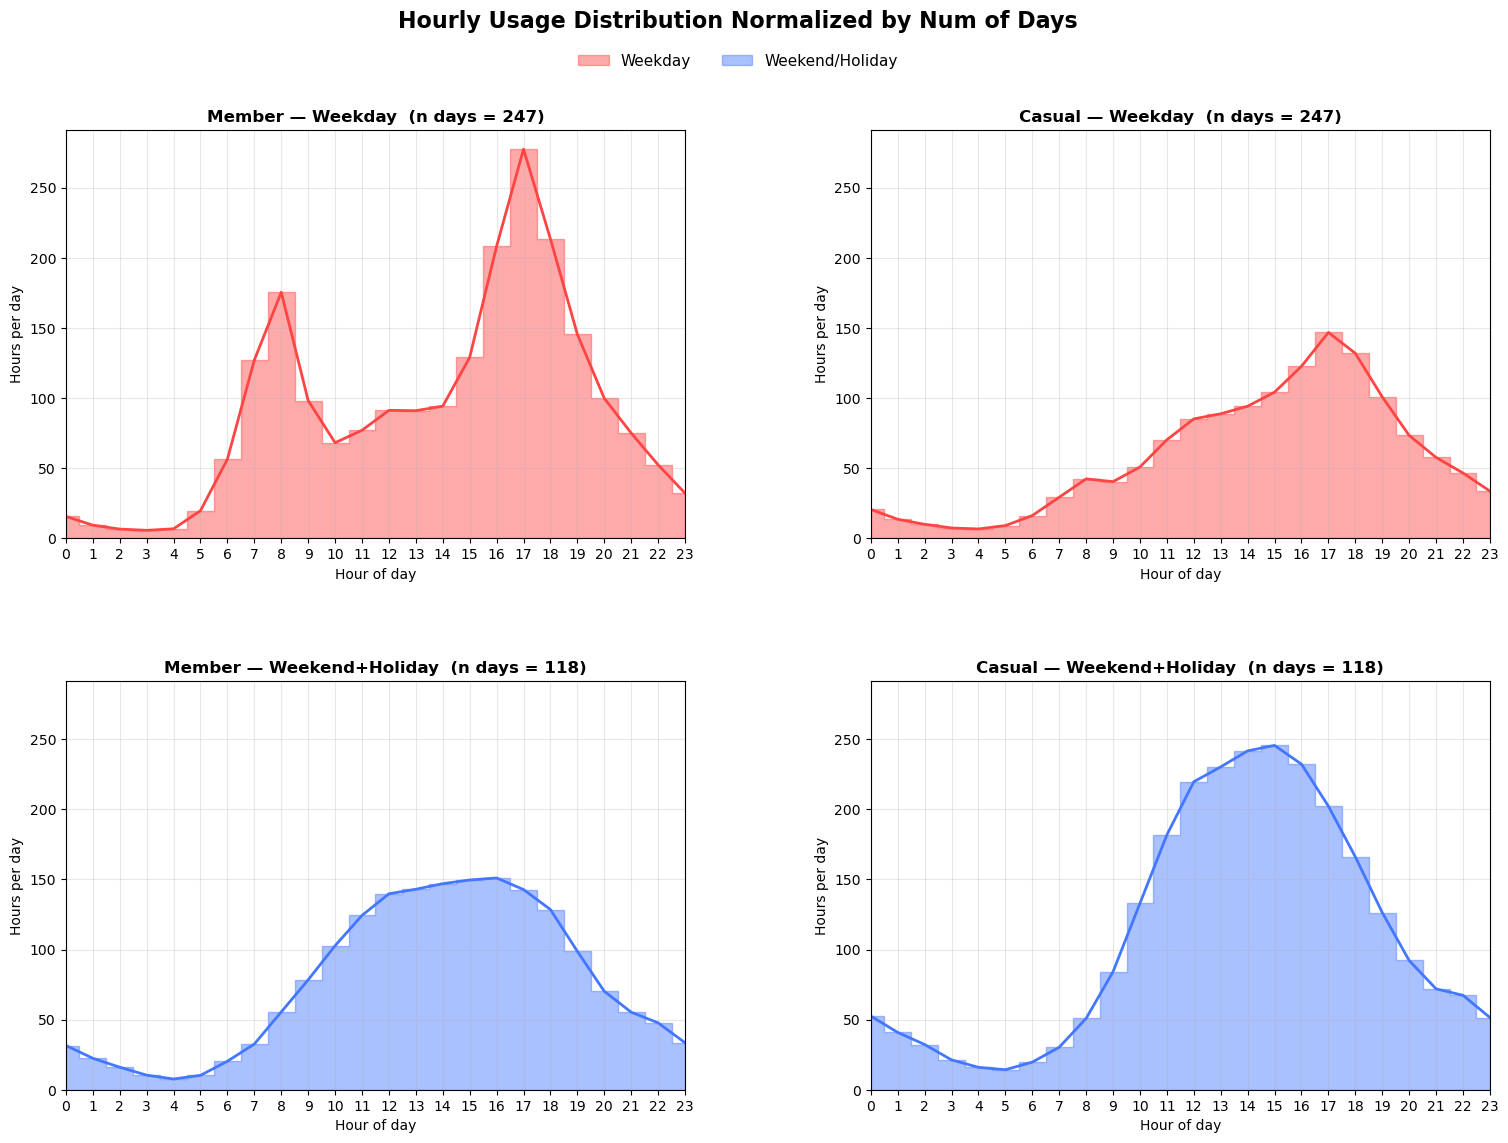

In [9]:
from numba import jit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import time

t_start = time.time()


# Create day_cat_simple if not already present
if 'day_cat_simple' not in df_clean.columns:
    df_clean['day_cat_simple'] = np.where(
        df_clean['day_category'] == 'weekday', 'weekday', 'weekend'
    )

# Encode groups as int32 (vectorized):
#    weekday+member=0 | weekday+casual=1 | weekend+member=2 | weekend+casual=3
df_clean['group_id'] = (
    df_clean['day_cat_simple'].map({'weekday': 0, 'weekend': 2}) +
    df_clean['member_casual'].map({'member': 0, 'casual': 1})
).astype(np.int32)

GROUP_NAMES = ['weekday_member', 'weekday_casual', 'weekend_member', 'weekend_casual']
N_GROUPS    = 4

# Unique days per group — single groupby
days_per_group = (
    df_clean.groupby('group_id')['ride_date']
    .nunique()
    .reindex(range(N_GROUPS), fill_value=0)   # ensures order 0–3
    .values
)

for i, name in enumerate(GROUP_NAMES):
    rides = (df_clean['group_id'] == i).sum()
    tag = '(weekend + holiday)' if 'weekend' in name else ''
    print(f"  → {name:<20}: {rides:>8,} rides | {days_per_group[i]:>4} days {tag}")


@jit(nopython=True)
def sum_minutes_all_groups(start_minutes, durations, group_ids, n_groups):
    """
    Single pass over the full dataset.
    Output: array (n_groups, 24) with total minutes per hour per group.
    """
    totals    = np.zeros((n_groups, 24), dtype=np.float64)
    day_minutes = 24 * 60

    for i in range(len(start_minutes)):
        g              = group_ids[i]
        current_minute = int(start_minutes[i]) % day_minutes
        remaining      = float(durations[i])

        while remaining > 1e-9:
            current_hour        = int((current_minute // 60) % 24)
            minute_in_hour      = int(current_minute % 60)
            minutes_left_in_hour = float(60 - minute_in_hour)

            alloc = minutes_left_in_hour if remaining >= minutes_left_in_hour else remaining

            totals[g, current_hour] += alloc
            remaining      -= alloc
            current_minute  = int((current_minute + alloc) % day_minutes)

    return totals

# Prepara gli array numpy — started_at già convertito in datetime
start_minutes = (
    df_clean['started_at'].dt.hour * 60 +
    df_clean['started_at'].dt.minute
).values.astype(np.int32)

durations  = df_clean['trip_duration'].values.astype(np.float64)
group_ids  = df_clean['group_id'].values.astype(np.int32)

# Single call — processes all 4 groups together
totals = sum_minutes_all_groups(start_minutes, durations, group_ids, N_GROUPS)


all_results = {}

for g, name in enumerate(GROUP_NAMES):
    days = days_per_group[g]
    hours_per_day = (totals[g] / days / 60) if days > 0 else np.zeros(24)

    all_results[name] = pd.DataFrame({
        'hour':         np.arange(24),
        'hours_per_day': hours_per_day,
        'unique_days':  days
    })

max_y_value = max(df['hours_per_day'].max() for df in all_results.values())
y_max       = max_y_value * 1.05 if max_y_value > 0 else 1

for name, df_r in all_results.items():
    peak_hour = df_r['hours_per_day'].idxmax()
    peak_val  = df_r['hours_per_day'].max()
    print(f"  → {name:<20}: peak hour {peak_hour:02d}:00 → {peak_val:.3f} h/day")

colors = {
    'weekday_member': '#ff4444',
    'weekday_casual': '#ff4444',
    'weekend_member': '#4477ff',
    'weekend_casual': '#4477ff'
}

titles = {
    'weekday_member': 'Member',
    'weekday_casual': 'Casual',
    'weekend_member': 'Member',
    'weekend_casual': 'Casual'
}


fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, (name, hour_usage) in enumerate(all_results.items()):
    ax    = axes[i]
    color = colors[name]
    day_label = 'Weekday' if 'weekday' in name else 'Weekend+Holiday'

    ax.fill_between(
        hour_usage['hour'],
        hour_usage['hours_per_day'],
        step='mid',
        alpha=0.45,
        color=color
    )
    ax.plot(
        hour_usage['hour'],
        hour_usage['hours_per_day'],
        color=color,
        linewidth=2
    )

    ax.set_xlim(0, 23)
    ax.set_ylim(0, y_max)
    ax.set_xticks(range(24))
    ax.set_xlabel('Hour of day')
    ax.set_ylabel('Hours per day')
    ax.set_title(
        f"{titles[name]} — {day_label}  (n days = {hour_usage['unique_days'].iloc[0]})",
        fontsize=12,
        fontweight='bold'
    )
    ax.grid(True, alpha=0.3)

for ax in axes:
    ax.tick_params(axis='x', which='both', labelbottom=True)
    ax.tick_params(axis='y', which='both', labelleft=True)

plt.suptitle(
    'Hourly Usage Distribution Normalized by Num of Days',
    fontsize=16, fontweight='bold', y=0.98
)

legend_elements = [
    Patch(facecolor='#ff4444', edgecolor='#ff4444', alpha=0.45, label='Weekday'),
    Patch(facecolor='#4477ff', edgecolor='#4477ff', alpha=0.45, label='Weekend/Holiday')
]
fig.legend(
    handles=legend_elements, loc='upper center',
    ncol=2, frameon=False,
    bbox_to_anchor=(0.5, 0.955), fontsize=11
)

plt.subplots_adjust(left=0.08, right=0.97, top=0.88,
                    bottom=0.08, wspace=0.30, hspace=0.35)
plt.savefig('../reports/figures/hourly_usage_weekday_vs_weekend.png', dpi=150, bbox_inches='tight')
plt.show()

results_normalized = pd.concat(all_results, names=['dataset'])
results_normalized.to_csv('../data/processed/hourly_usage.csv')

# Remove temporary columns
df_clean.drop(columns=['group_id'], inplace=True)



In [10]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import pandas as pd
import time

t0 = time.time()

# Constants
GROUP_NAMES  = ['weekday_member', 'weekday_casual', 'weekend_member', 'weekend_casual']
SUBPLOT_POS  = {'weekday_member': (1,1), 'weekday_casual': (1,2),
                'weekend_member': (2,1), 'weekend_casual': (2,2)}
TITLES_MAP   = {'weekday_member': 'Member — Weekday',
                'weekday_casual': 'Casual — Weekday',
                'weekend_member': 'Member — Weekend + Holiday',
                'weekend_casual': 'Casual — Weekend + Holiday'}
COLOR_LINE   = {'weekday_member': '#e63333', 'weekday_casual': '#e63333',
                'weekend_member': '#3366dd', 'weekend_casual': '#3366dd'}
COLOR_FILL   = {'weekday_member': 'rgba(230,51,51,0.25)',  'weekday_casual': 'rgba(230,51,51,0.25)',
                'weekend_member': 'rgba(51,102,221,0.25)', 'weekend_casual': 'rgba(51,102,221,0.25)'}

# Helpers
def ensure_group_id(df):
    """Rebuild group_id if removed by previous steps."""
    if 'group_id' not in df.columns:
        if 'day_cat_simple' not in df.columns:
            df = df.copy()
            df['day_cat_simple'] = np.where(df['day_category'] == 'weekday', 'weekday', 'weekend')
        df['group_id'] = (
            df['day_cat_simple'].map({'weekday': 0, 'weekend': 2}) +
            df['member_casual'].map({'member': 0, 'casual': 1})
        ).astype(np.int32)
    return df

def compute_hourly(df_subset):
    """
    Returns dict {group_name: array(24) hours_per_day}
    for a subset of the dataframe.
    """
    if df_subset.empty:
        return {name: np.zeros(24) for name in GROUP_NAMES}

    start_min  = (df_subset['started_at'].dt.hour * 60 +
                  df_subset['started_at'].dt.minute).values.astype(np.int32)
    durations  = df_subset['trip_duration'].values.astype(np.float64)
    group_ids  = df_subset['group_id'].values.astype(np.int32)
    days_pg    = (df_subset.groupby('group_id')['ride_date']
                  .nunique()
                  .reindex(range(4), fill_value=0)
                  .values)

    totals = sum_minutes_all_groups(start_min, durations, group_ids, 4)

    return {
        name: (totals[g] / days_pg[g] / 60) if days_pg[g] > 0 else np.zeros(24)
        for g, name in enumerate(GROUP_NAMES)
    }

# Prepare data for each month + "All"
df_work = ensure_group_id(df_clean)

months_sorted = sorted(df_work['started_at'].dt.to_period('M').unique().astype(str))
month_options = ['All'] + months_sorted

print(f"  → Months available : {len(months_sorted)}  ({months_sorted[0]} → {months_sorted[-1]})")

monthly_data = {'All': compute_hourly(df_work)}
for month in months_sorted:
    mask = df_work['started_at'].dt.to_period('M').astype(str) == month
    monthly_data[month] = compute_hourly(df_work[mask])

print(f"  → Datasets computed: {len(monthly_data)}  (All + {len(months_sorted)} months)")

# Global y_max (consistent scale across all filters)
y_max_global = max(
    v.max()
    for month_dict in monthly_data.values()
    for v in month_dict.values()
) * 1.12

# Build Plotly figure
HOURS = list(range(24))
N_OPTIONS = len(month_options)   # All + mesi
N_GROUPS  = len(GROUP_NAMES)
N_TRACES  = N_OPTIONS * N_GROUPS  # total traces

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=list(TITLES_MAP.values()),
    shared_xaxes=True,
    shared_yaxes=True,
    vertical_spacing=0.12,
    horizontal_spacing=0.06,
)

# Add fill+line pair for each (month, group)
trace_idx = 0
month_trace_map = {}   # month → [indici tracce]

for month in month_options:
    indices = []
    for g_name in GROUP_NAMES:
        row, col = SUBPLOT_POS[g_name]
        y_data   = monthly_data[month][g_name]
        visible  = (month == 'All')

        # Fill sotto la curva
        fig.add_trace(go.Scatter(
            x=HOURS, y=y_data,
            mode='none',
            fill='tozeroy',
            fillcolor=COLOR_FILL[g_name],
            showlegend=False,
            visible=visible,
            hoverinfo='skip',
        ), row=row, col=col)
        indices.append(trace_idx); trace_idx += 1

        # Linea principale
        fig.add_trace(go.Scatter(
            x=HOURS, y=y_data,
            mode='lines',
            line=dict(color=COLOR_LINE[g_name], width=2.2),
            name=g_name,
            showlegend=False,
            visible=visible,
            hovertemplate='<b>Hour %{x}:00</b><br>%{y:.3f} h/day<extra></extra>',
        ), row=row, col=col)
        indices.append(trace_idx); trace_idx += 1

    month_trace_map[month] = indices

# Dropdown buttons
buttons = []
for month in month_options:
    visible_flags = [i in month_trace_map[month] for i in range(N_TRACES)]
    label = '📅 ' + month if month != 'All' else '🗂 All months'
    buttons.append(dict(
        label=label,
        method='update',
        args=[
            {'visible': visible_flags},
            {'title': {'text': f'Hourly Usage — {month}', 'font': {'size': 18}}}
        ]
    ))

# Layout
fig.update_layout(
    title=dict(text='Hourly Usage Distribution — All months', font=dict(size=18), x=0.5),
    height=680,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    updatemenus=[dict(
        type='dropdown',
        direction='down',
        x=0.5, xanchor='center',
        y=1.08, yanchor='top',
        bgcolor='white',
        bordercolor='#cccccc',
        font=dict(size=12),
        buttons=buttons,
        active=0,
    )],
    annotations=[dict(
        text='Month filter →',
        x=0.31, xanchor='right',
        y=1.085, yanchor='top',
        xref='paper', yref='paper',
        showarrow=False,
        font=dict(size=12, color='#555')
    )],
    margin=dict(t=120, b=60, l=60, r=30),
)

# Uniform X and Y axes for all subplots
for row in [1, 2]:
    for col in [1, 2]:
        fig.update_xaxes(
            title_text='Hour of day' if row == 2 else '',
            tickvals=list(range(0, 24, 2)),
            ticktext=[f'{h:02d}:00' for h in range(0, 24, 2)],
            tickangle=45, gridcolor='#eeeeee',
            row=row, col=col
        )
        fig.update_yaxes(
            title_text='h / day' if col == 1 else '',
            range=[0, y_max_global],
            gridcolor='#eeeeee',
            row=row, col=col
        )

# Color subplot titles
for ann in fig.layout.annotations[:4]:
    ann.update(font=dict(size=13, color='#222'))

fig.write_html('../reports/cyclistic_hourly_interactive.html')
fig.show()

print(f"\n✅ Saved: ../reports/cyclistic_hourly_interactive.html")
print(f"   → {N_TRACES} total traces ({N_OPTIONS} options × {N_GROUPS} groups × 2 layer fill/line)")


  → Months available : 12  (2025-06 → 2026-05)


  → Datasets computed: 13  (All + 12 months)



✅ Saved: ../reports/cyclistic_hourly_interactive.html
   → 52 total traces (13 options × 4 groups × 2 layer fill/line)


## 2.2 Pattern Stagionali (Mensile) <a id='monthly'></a>
[↑ back to top](#toc)

Stabilito *quando* durante la giornata ciascun gruppo pedala, voglio ora guardare
*quali mesi* mostrano i picchi più alti. Mi aspetto che i casual abbiano una curva
stagionale più ripida — il loro utilizzo è più sensibile al meteo e legato
al turismo — mentre i member dovrebbero mantenersi più costanti durante l'anno.


  → Months in dataset  : 12


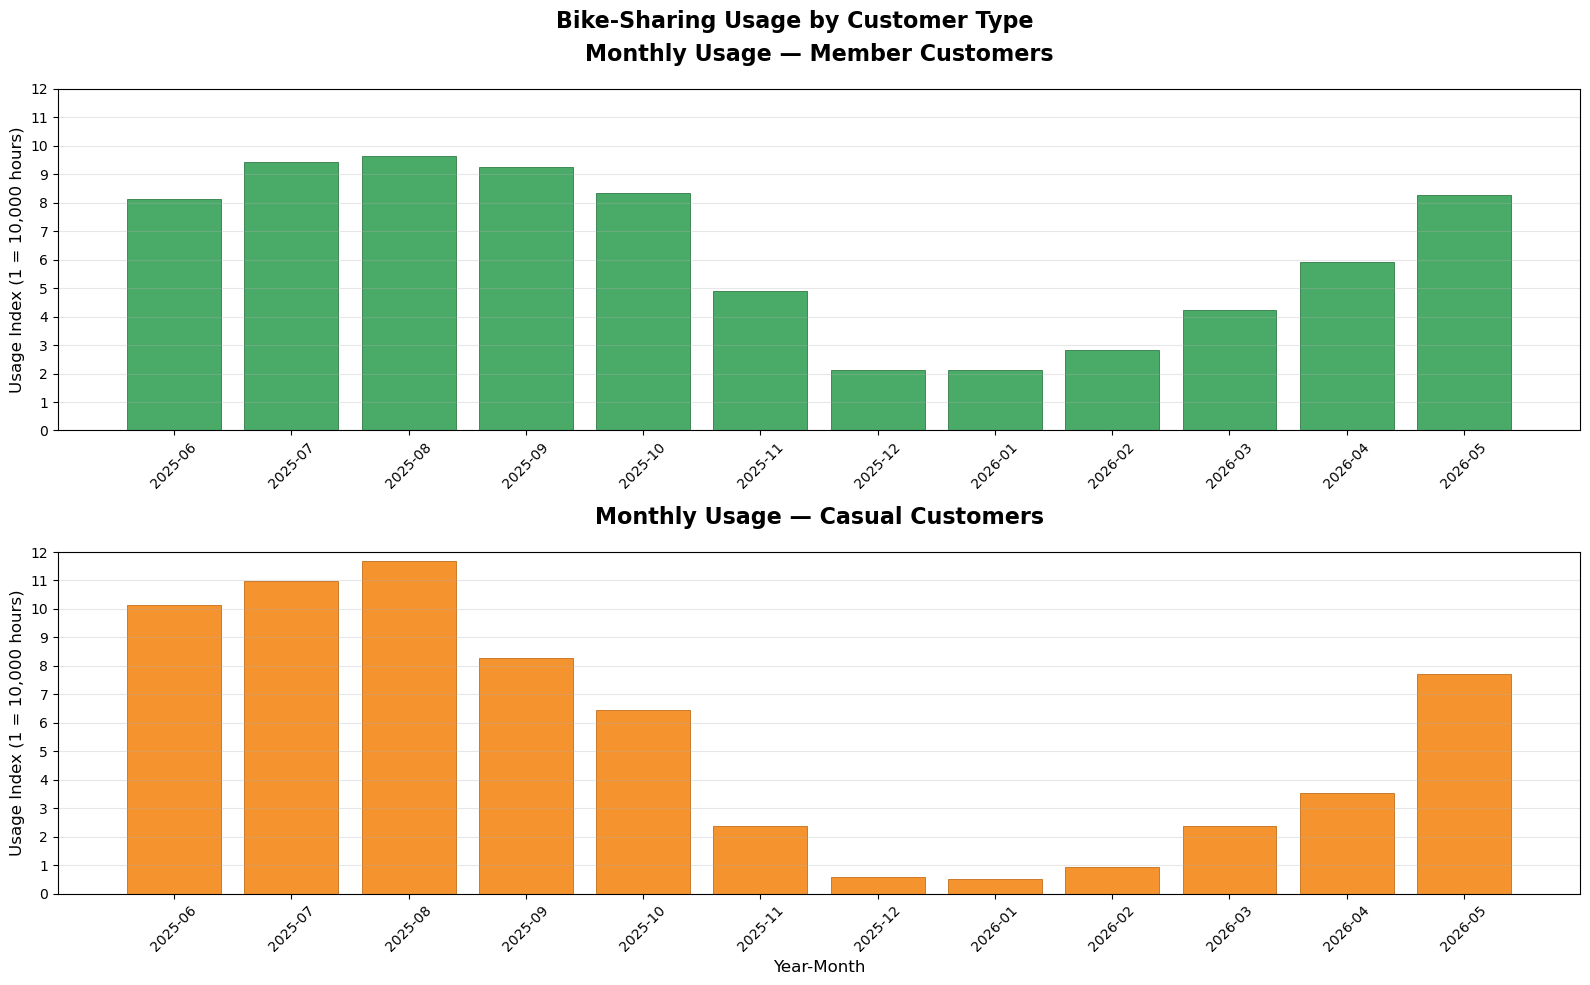

  → ../reports/figures/monthly_usage_member_vs_casual.png
  → ../data/processed/monthly_usage.csv

  Last 5 months (most recent):
Year_Month  Member_Hours  Casual_Hours
   2026-01  21183.645333   5177.130667
   2026-02  28165.309667   9409.160333
   2026-03  42211.675000  23853.613667
   2026-04  59281.240667  35257.664833
   2026-05  82684.257500  77208.785500


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter
from numba import njit
import time

t_start = time.time()


@njit
def compute_minutes(start_ns, end_ns):
    """
    Compute trip duration in minutes from nanosecond timestamps.
    If end <= start -> duration 0 (invalid row).
    """
    n        = len(start_ns)
    out      = np.empty(n, dtype=np.float64)
    minute_ns = 60 * 1_000_000_000

    for i in range(n):
        s = start_ns[i]
        e = end_ns[i]
        out[i] = 0.0 if e <= s else (e - s) / minute_ns

    return out




def prepare_monthly_usage(df_clean):
    """
    Return (month_labels, member_values, casual_values).
    Never modifies df_clean (works on an internal copy).

    Logic:
    - If trip_duration already exists, use it directly (avoids recomputation).
    - Otherwise compute it with Numba from started_at / ended_at.
    - Filter rows with duration <= 0 (invalid trips).
    - Aggregate by chronological month and user type via pivot_table.
    """
    t0 = time.time()

    # Work on a copy — df_clean original is never modified
    df = df_clean.copy()

    # Verify required columns are present
    required_cols = {'started_at', 'member_casual'}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns in df_clean: {missing}")

    # Convert datetime only if needed (skip if already datetime)
    if not pd.api.types.is_datetime64_any_dtype(df['started_at']):
        df['started_at'] = pd.to_datetime(df['started_at'])

    # Use trip_duration if present, otherwise recompute with Numba
    if 'trip_duration' in df.columns:
        df['minutes'] = df['trip_duration'].astype(np.float64)
    else:
        if not pd.api.types.is_datetime64_any_dtype(df['ended_at']):
            df['ended_at'] = pd.to_datetime(df['ended_at'])
        start_ns     = df['started_at'].values.astype('datetime64[ns]').astype('int64')
        end_ns       = df['ended_at'].values.astype('datetime64[ns]').astype('int64')
        df['minutes'] = compute_minutes(start_ns, end_ns)

    # Filter rows with invalid duration
    invalid_count = (df['minutes'] <= 0).sum()
    if invalid_count > 0:
        df = df[df['minutes'] > 0]

    # Create month column (Period 'M' ensures correct chronological order)
    df['year_month'] = df['started_at'].dt.to_period('M')

    # Pivot: rows=months, columns=member/casual, values=total minutes
    pivot = (
        df.pivot_table(
            index='year_month',
            columns='member_casual',
            values='minutes',
            aggfunc='sum',
            fill_value=0.0
        )
        .sort_index()   # ensures chronological order
    )

    month_labels  = pivot.index.astype(str).tolist()
    member_values = pivot.get('member', pd.Series(0.0, index=pivot.index)).to_numpy()
    casual_values = pivot.get('casual', pd.Series(0.0, index=pivot.index)).to_numpy()

    return month_labels, member_values, casual_values


t0 = time.time()

month_labels, member_values, casual_values = prepare_monthly_usage(df_clean)

member_hours = member_values / 60
casual_hours = casual_values / 60

print(f"\n  → Months in dataset  : {len(month_labels)}")


max_hours = max(
    member_hours.max() if len(member_hours) > 0 else 0,
    casual_hours.max() if len(casual_hours) > 0 else 0
)
y_max = int(np.ceil(max_hours / 10000.0) * 10000)
if y_max == 0:
    y_max = 10000


def usage_index_formatter(y, pos):
    return f"{y / 10000:.0f}"


# ✅ COLORI:
#    member → verde  (#2a9d4e  fill  |  #1a6b32  edge)
#    casual → arancione (#f4820a  fill  |  #b85e05  edge)
t0 = time.time()

COLOR_MEMBER_FILL = '#2a9d4e'
COLOR_MEMBER_EDGE = '#1a6b32'
COLOR_CASUAL_FILL = '#f4820a'
COLOR_CASUAL_EDGE = '#b85e05'

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# ── Member (top) ──
ax1.bar(
    month_labels,
    member_hours,
    color=COLOR_MEMBER_FILL,
    alpha=0.85,
    edgecolor=COLOR_MEMBER_EDGE,
    linewidth=0.6
)
ax1.set_title('Monthly Usage — Member Customers', fontsize=16, fontweight='bold', pad=20)
ax1.set_ylabel('Usage Index (1 = 10,000 hours)', fontsize=12)
ax1.set_ylim(0, y_max)
ax1.yaxis.set_major_locator(MultipleLocator(10000))
ax1.yaxis.set_major_formatter(FuncFormatter(usage_index_formatter))
ax1.grid(True, axis='y', alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# ── Casual (bottom) ──
ax2.bar(
    month_labels,
    casual_hours,
    color=COLOR_CASUAL_FILL,
    alpha=0.85,
    edgecolor=COLOR_CASUAL_EDGE,
    linewidth=0.6
)
ax2.set_title('Monthly Usage — Casual Customers', fontsize=16, fontweight='bold', pad=20)
ax2.set_ylabel('Usage Index (1 = 10,000 hours)', fontsize=12)
ax2.set_xlabel('Year-Month', fontsize=12)
ax2.set_ylim(0, y_max)
ax2.yaxis.set_major_locator(MultipleLocator(10000))
ax2.yaxis.set_major_formatter(FuncFormatter(usage_index_formatter))
ax2.grid(True, axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.suptitle(
    'Bike-Sharing Usage by Customer Type',
    fontsize=16, fontweight='bold', y=0.98
)

plt.tight_layout()
plt.savefig('../reports/figures/monthly_usage_member_vs_casual.png', dpi=150, bbox_inches='tight')
plt.show()


monthly_data = pd.DataFrame({
    'Year_Month'   : month_labels,
    'Member_Hours' : member_hours,
    'Casual_Hours' : casual_hours
})
monthly_data.to_csv('../data/processed/monthly_usage.csv', index=False)

print("  → ../reports/figures/monthly_usage_member_vs_casual.png")
print("  → ../data/processed/monthly_usage.csv")
print("\n  Last 5 months (most recent):")
print(monthly_data.tail().to_string(index=False))

---
# 3. Analisi Spaziale: Zoning Districts di Chicago <a id='spatial'></a>
[↑ back to top](#toc)

I pattern temporali mi hanno detto *quando* ciascun gruppo pedala.
Ora voglio capire *dove*: member e casual partono e arrivano in zone
strutturalmente diverse della città?

Ogni viaggio viene geolocalizzato usando il dataset di zoning di Chicago
(14.757 poligoni). Lo spatial join assegna a ciascuna partenza e arrivo
il distretto di zoning corrispondente.

## 3.1 Caricamento Dati e Spatial Join <a id='join'></a>
[↑ back to top](#toc)

**Dati:** `gdf_zoning_updated.csv` da `../data/interim/` — 14.757 poligoni di zoning
con etichette `zone_name` semplificate.

**Metodo:** spatial join GeoPandas (`sjoin` con `predicate="within"`) — assegna
a ciascuna partenza e arrivo il distretto di zoning corrispondente.

In [12]:
import pandas as pd
import geopandas as gpd

zoning_path = "../data/interim/gdf_zoning_updated.csv"
zoning_df   = pd.read_csv(zoning_path)

print(f"Zoning caricato — {len(zoning_df):,} distretti, {zoning_df.columns.tolist()}")

Zoning caricato — 14,875 distretti, ['the_geom', 'case_numbe', 'case_type', 'zoning_id', 'zone_name', 'zone_type', 'zone_class', 'edit_statu', 'create_dat', 'edit_date', 'pd_prefix', 'pd_num', 'comments', 'ordinance_', 'ordinance1', 'zoning_rel', 'shape_area', 'shape_len', 'pedstreet_', 'objectid', 'globalid', 'pmd_sub_ar', 'override_c', 'override_r', 'clerk_url', 'clerk_docn']


In [13]:
required_cols = {"the_geom", "zone_type", "zone_name"}
missing = required_cols - set(zoning_df.columns)
if missing:
    raise ValueError(f"Colonne mancanti: {sorted(missing)}")

geometry = gpd.GeoSeries.from_wkt(zoning_df["the_geom"], crs="EPSG:4326")
zoning = gpd.GeoDataFrame(
    zoning_df[["zone_type", "zone_name"]].copy(),
    geometry=geometry,
    crs="EPSG:4326"
)

print(f"GeoDataFrame creato — {len(zoning):,} poligoni")
print(f"  zone_name: {zoning['zone_name'].nunique()} uniche | zone_type: {zoning['zone_type'].nunique()} unici")
print(f"  CRS: {zoning.crs}")

GeoDataFrame creato — 14,875 poligoni
  zone_name: 7 uniche | zone_type: 12 unici
  CRS: EPSG:4326


In [14]:
df_clean = df_clean.reset_index(drop=True).copy()

coord_cols = ["start_lat", "start_lng", "end_lat", "end_lng"]
available  = [c for c in coord_cols if c in df_clean.columns]
missing_c  = [c for c in coord_cols if c not in df_clean.columns]
if missing_c:
    print(f"  ⚠ Colonne coordinate mancanti: {missing_c}")

print(f"df_clean pronto — {len(df_clean):,} viaggi, {len(df_clean.columns)} colonne")

df_clean pronto — 5,680,076 viaggi, 18 colonne


In [15]:
gdf_starts = gpd.GeoDataFrame(
    df_clean.copy(),
    geometry=gpd.points_from_xy(df_clean["start_lng"], df_clean["start_lat"]),
    crs="EPSG:4326",
)
gdf_ends = gpd.GeoDataFrame(
    df_clean.copy(),
    geometry=gpd.points_from_xy(df_clean["end_lng"], df_clean["end_lat"]),
    crs="EPSG:4326",
)
print(f"GeoDataFrame partenze: {len(gdf_starts):,} | arrivi: {len(gdf_ends):,}")

GeoDataFrame partenze: 5,680,076 | arrivi: 5,680,076


In [16]:
if gdf_starts.crs != zoning.crs:
    print("⚠️ CRS mismatch!")
    gdf_starts = gdf_starts.to_crs(zoning.crs)

In [17]:
spat_starts = gpd.sjoin(gdf_starts, zoning, how="left", predicate="within")
spat_starts = spat_starts[~spat_starts.index.duplicated(keep="first")]

df_clean["start_zone_name"] = spat_starts["zone_name"].reindex(df_clean.index)
df_clean["start_zone_type"] = spat_starts["zone_type"].reindex(df_clean.index)

matched = df_clean["start_zone_name"].notna().sum()
print(f"Spatial join partenze — {matched:,} / {len(df_clean):,} match ({matched/len(df_clean)*100:.1f}%)")

Spatial join partenze — 5,577,598 / 5,680,076 match (98.2%)


In [18]:
spat_ends = gpd.sjoin(gdf_ends, zoning, how="left", predicate="within")
spat_ends = spat_ends[~spat_ends.index.duplicated(keep="first")]

df_clean["end_zone_name"] = spat_ends["zone_name"].reindex(df_clean.index)
df_clean["end_zone_type"] = spat_ends["zone_type"].reindex(df_clean.index)

matched_e = df_clean["end_zone_name"].notna().sum()
print(f"Spatial join arrivi   — {matched_e:,} / {len(df_clean):,} match ({matched_e/len(df_clean)*100:.1f}%)")

Spatial join arrivi   — 5,574,960 / 5,680,076 match (98.1%)


In [19]:
df_zoning = df_clean[
    df_clean[["start_zone_name", "end_zone_name", "start_zone_type", "end_zone_type"]].notna().all(axis=1)
].copy()

member_zoning = df_zoning[df_zoning['member_casual'] == 'member'].copy()
casual_zoning = df_zoning[df_zoning['member_casual'] == 'casual'].copy()

print(f"Viaggi con zona valida: {len(df_zoning):,}  (member: {len(member_zoning):,} | casual: {len(casual_zoning):,})")

Viaggi con zona valida: 5,528,865  (member: 3,591,122 | casual: 1,937,743)


In [20]:

n_member = len(member_zoning)
n_casual = len(casual_zoning)

print(f"Member rides: {n_member:,} | Casual rides: {n_casual:,} | Ratio: {n_member/n_casual:.1f}x")

# =============================================================================
# Top 10 start → end zone patterns for MEMBER rides
# =============================================================================
member_patterns = (
    member_zoning[["start_zone_name", "end_zone_name"]]
    .value_counts()
    .reset_index(name="rides")
)
member_patterns['pattern'] = (
    member_patterns['start_zone_name'] + ' → ' + 
    member_patterns['end_zone_name']
)
member_patterns['pct_member'] = (member_patterns['rides'] / n_member * 100).round(2)

# =============================================================================
# CASUAL: TOP 10 pattern (start_zone_name → end_zone_name)
# =============================================================================
casual_patterns = (
    casual_zoning[["start_zone_name", "end_zone_name"]]
    .value_counts()
    .reset_index(name="rides")
)
casual_patterns['pattern'] = (
    casual_patterns['start_zone_name'] + ' → ' + 
    casual_patterns['end_zone_name']
)
casual_patterns['pct_casual'] = (casual_patterns['rides'] / n_casual * 100).round(2)

print("\nTOP 10 MEMBER (% sul totale member):")
print(member_patterns[['pattern', 'rides', 'pct_member']].head(10).to_string(index=False))

print("\nTOP 10 CASUAL (% sul totale casual):")
print(casual_patterns[['pattern', 'rides', 'pct_casual']].head(10).to_string(index=False))

Member rides: 3,591,122 | Casual rides: 1,937,743 | Ratio: 1.9x



TOP 10 MEMBER (% sul totale member):
                                                          pattern  rides  pct_member
Planned Manufacturing Districts → Planned Manufacturing Districts 660872       18.40
                                              Business → Business 269110        7.49
                       Planned Manufacturing Districts → Business 258495        7.20
                       Business → Planned Manufacturing Districts 250017        6.96
                       Downtown → Planned Manufacturing Districts 227076        6.32
                       Planned Manufacturing Districts → Downtown 225728        6.29
                    Residential → Planned Manufacturing Districts 148594        4.14
                    Planned Manufacturing Districts → Residential 148585        4.14
                                           Residential → Business 129882        3.62
                                           Business → Residential 129784        3.61

TOP 10 CASUAL (% sul total

In [21]:

# BUG FIX: use zone_name directly instead of zone_type.
# The previous version used zone_type (numeric 1–12) and then renamed rows/columns
# via zone_labels. Because zone_types 7–10 all map to "Downtown" and 5,6,12 to
# "Planned Manufacturing Districts", the subsequent groupby().sum() stacked
# 3–4 already-100% rows → row sums reached 300–400 %. Fixed: build the
# crosstab from zone_name directly; no grouping step is needed.
member_readable = pd.crosstab(
    member_zoning['start_zone_name'],
    member_zoning['end_zone_name'],
    normalize='index'
) * 100

casual_readable = pd.crosstab(
    casual_zoning['start_zone_name'],
    casual_zoning['end_zone_name'],
    normalize='index'
) * 100

# Align both matrices to the same zone set (absent zones filled with 0)
all_zones       = sorted(set(member_readable.index) | set(casual_readable.index))
member_readable = member_readable.reindex(index=all_zones, columns=all_zones, fill_value=0.0)
casual_readable = casual_readable.reindex(index=all_zones, columns=all_zones, fill_value=0.0)

print(f"  → Zones          : {all_zones}")
print(f"  → Shape          : {member_readable.shape}")
row_sum_m = member_readable.sum(axis=1).round(1).to_dict()
row_sum_c = casual_readable.sum(axis=1).round(1).to_dict()
print(f"  → Row-sum member : {row_sum_m}")
print(f"  → Row-sum casual : {row_sum_c}")
print("  ✅ Each row sums to ~100 % — normalisation correct")


  → Zones          : ['Business', 'Commercial', 'Downtown', 'Manufacturing', 'Planned Manufacturing Districts', 'Residential', 'Transportation']
  → Shape          : (7, 7)
  → Row-sum member : {'Business': 100.0, 'Commercial': 100.0, 'Downtown': 100.0, 'Manufacturing': 100.0, 'Planned Manufacturing Districts': 100.0, 'Residential': 100.0, 'Transportation': 100.0}
  → Row-sum casual : {'Business': 100.0, 'Commercial': 100.0, 'Downtown': 100.0, 'Manufacturing': 100.0, 'Planned Manufacturing Districts': 100.0, 'Residential': 100.0, 'Transportation': 100.0}
  ✅ Each row sums to ~100 % — normalisation correct


## 3.2 Statistical Validation — Chi-Square Test <a id='chi2'></a>
[↑ back to top](#toc)


Before investing in visual analysis, we formally test whether the observed zone distribution  
differences between members and casuals are statistically significant or could be due to chance.

**H₀:** the start zone distribution is independent of user type (member vs. casual).  
A very low p-value (< 0.001) rejects H₀ and confirms the differences are real.

In [22]:

from scipy.stats import chi2_contingency

contingency_start = pd.crosstab(
    pd.concat([member_zoning['start_zone_type'], casual_zoning['start_zone_type']]),
    pd.Series(['MEMBER']*len(member_zoning) + ['CASUAL']*len(casual_zoning))
)

chi2_start, p_start, dof_start, _ = chi2_contingency(contingency_start)
print(f"START zone_type → Chi²={chi2_start:.0f}, p={p_start:.2e} {'✅ SIGNIFICANT' if p_start<0.001 else '❌'}")

contingency_end = pd.crosstab(
    pd.concat([member_zoning['end_zone_type'], casual_zoning['end_zone_type']]),
    pd.Series(['MEMBER']*len(member_zoning) + ['CASUAL']*len(casual_zoning))
)

chi2_end, p_end, dof_end, _ = chi2_contingency(contingency_end)
print(f"END zone_type → Chi²={chi2_end:.0f}, p={p_end:.2e} {'✅ SIGNIFICANT' if p_end<0.001 else '❌ not significant'}")

START zone_type → Chi²=20605, p=0.00e+00 ✅ SIGNIFICANT


END zone_type → Chi²=21239, p=0.00e+00 ✅ SIGNIFICANT


## 3.3 Start Zone Distribution: Member vs Casual <a id='zones'></a>
[↑ back to top](#toc)


**Zoom:** the chi-square test confirmed that zone distributions differ significantly.  
This chart shows *which specific zones* account for that divergence:  
- Upper panel: raw % of rides starting from each zone (by user type).  
- Lower panel: divergence (member % − casual %) — green bars = member over-representation,  
  orange bars = casual over-representation.

  → Zone trovate             : 7
  → Most used zone (member): Planned Manufacturing Districts  (39.7%)
  → Most used zone (casual): Planned Manufacturing Districts  (46.6%)
  → Max divergence member  : Business  (+2.7%)
  → Max divergence casual  : Planned Manufacturing Districts  (+7.0%)


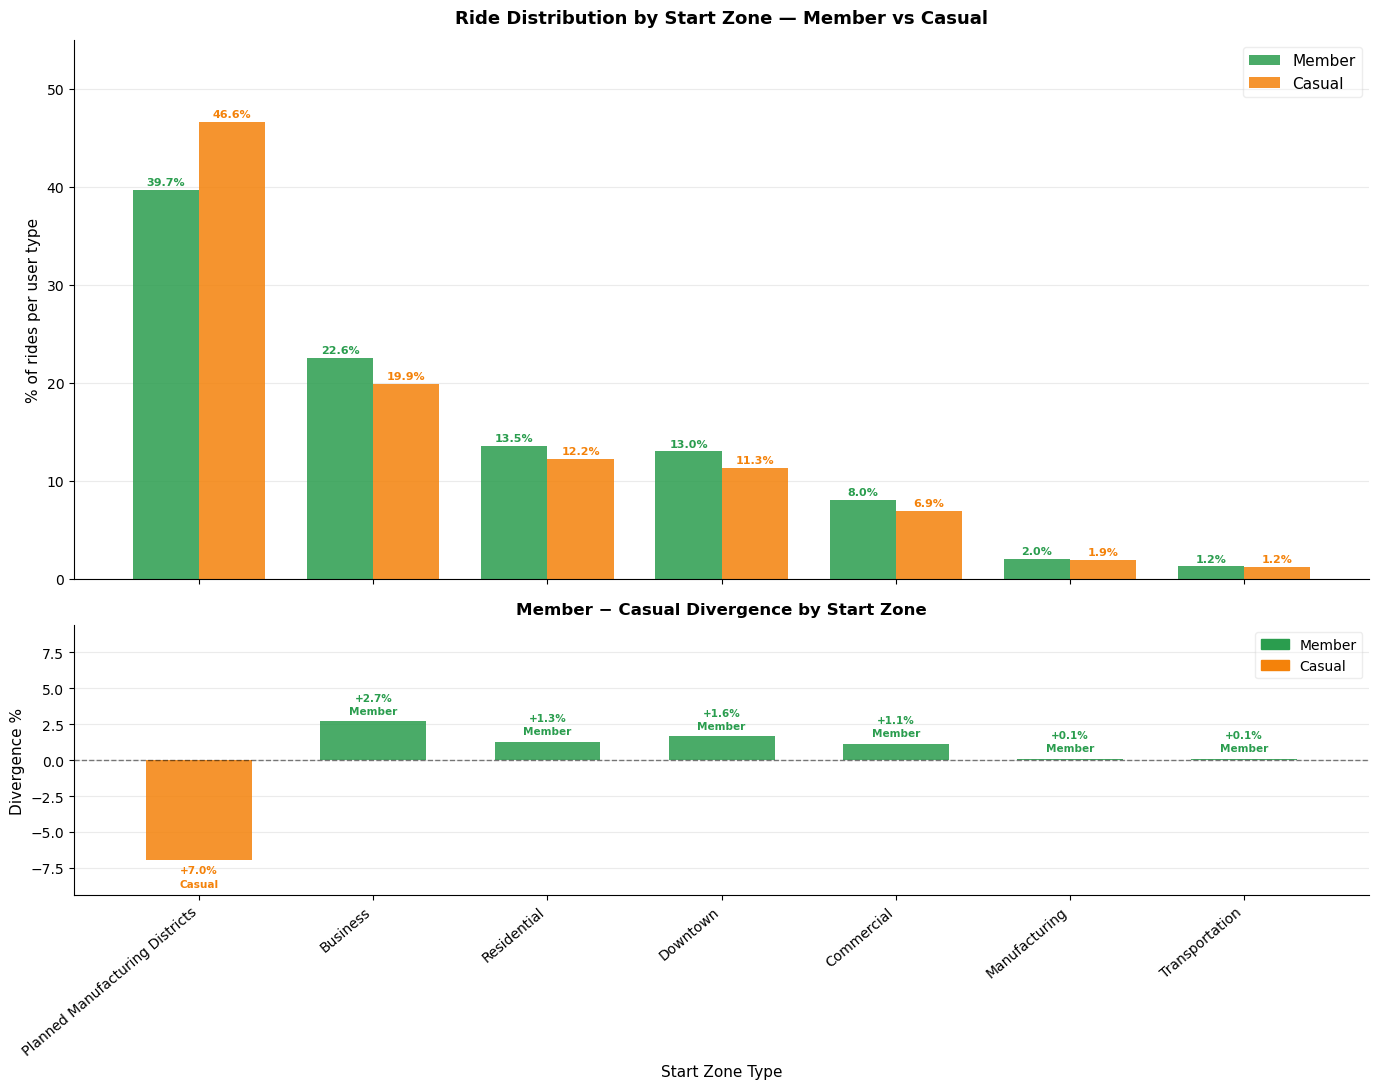


  Summary table (sorted by divergence):
                                 member_%  casual_%  divergence_%
start_zone_name                                                  
Business                             22.6      19.8          2.70
Downtown                             13.0      11.3          1.65
Residential                          13.5      12.2          1.27
Commercial                            8.0       6.9          1.14
Manufacturing                         2.0       1.9          0.11
Transportation                        1.2       1.2          0.09
Planned Manufacturing Districts      39.7      46.6         -6.95


In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import time

t0 = time.time()

# ── Calcolo distribuzione ───────────────────────────────────
start_dist = (
    df_clean
    .groupby(['start_zone_name', 'member_casual'])
    .size()
    .unstack(fill_value=0)
)
start_pct      = start_dist.div(start_dist.sum(axis=0), axis=1) * 100
start_pct      = start_pct.round(2).sort_values('member', ascending=False)
member_pct     = start_pct.get('member', pd.Series(0, index=start_pct.index))
casual_pct     = start_pct.get('casual', pd.Series(0, index=start_pct.index))
divergence_pct = (member_pct - casual_pct).round(2)

zones   = start_pct.index.tolist()
x       = np.arange(len(zones))

print(f"  → Zone trovate             : {len(zones)}")
print(f"  → Most used zone (member): {member_pct.idxmax()}  ({member_pct.max():.1f}%)")
print(f"  → Most used zone (casual): {casual_pct.idxmax()}  ({casual_pct.max():.1f}%)")
print(f"  → Max divergence member  : {divergence_pct.idxmax()}  ({divergence_pct.max():+.1f}%)")
print(f"  → Max divergence casual  : {divergence_pct.idxmin()}  ({abs(divergence_pct.min()):+.1f}%)")

# ── Costanti visive ─────────────────────────────────────────
BAR_W        = 0.38
COLOR_MEMBER = '#2a9d4e'
COLOR_CASUAL = '#f4820a'
LABEL_COLOR  = 'black'
COLOR_POS = COLOR_MEMBER  # Verde per valori positivi (predominanza member)
COLOR_NEG = COLOR_CASUAL  # Arancione per valori negativi (predominanza casual)

# ── Figure ──────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(14, 11),
    gridspec_kw={'height_ratios': [2, 1]},
    sharex=True
)
fig.subplots_adjust(hspace=0.08)

# ════════════════════════════════════════════════════════════
# AX1 — barre affiancate member vs casual
# ════════════════════════════════════════════════════════════
ax1.bar(x - BAR_W / 2, member_pct, width=BAR_W,
        color=COLOR_MEMBER, alpha=0.85, label='Member', zorder=2)
ax1.bar(x + BAR_W / 2, casual_pct, width=BAR_W,
        color=COLOR_CASUAL, alpha=0.85, label='Casual',  zorder=2)

y1_max = max(member_pct.max(), casual_pct.max())
ax1.set_ylim(0, y1_max * 1.18)
ax1.set_ylabel('% of rides per user type', fontsize=11)
ax1.set_title('Ride Distribution by Start Zone — Member vs Casual',
              fontweight='bold', fontsize=13, pad=12)
ax1.legend(fontsize=11, framealpha=0.35)
ax1.grid(axis='y', alpha=0.25, zorder=0)
ax1.spines[['top', 'right']].set_visible(False)

# Value labels on divergence bars
for i, (m, c) in enumerate(zip(member_pct, casual_pct)):
    ax1.text(i - BAR_W / 2, m + 0.3, f'{m:.1f}%',
             ha='center', va='bottom', fontsize=8, color=COLOR_MEMBER, fontweight='bold')
    ax1.text(i + BAR_W / 2, c + 0.3, f'{c:.1f}%',
             ha='center', va='bottom', fontsize=8, color=COLOR_CASUAL, fontweight='bold')

# ════════════════════════════════════════════════════════════
# AX2 — symmetric divergence bars
# ════════════════════════════════════════════════════════════
bar_colors = [COLOR_MEMBER if v >= 0 else COLOR_CASUAL for v in divergence_pct]
ax2.bar(x, divergence_pct, width=BAR_W * 1.6,
        color=bar_colors, alpha=0.85, zorder=2)
ax2.axhline(0, color='black', linewidth=1.0, linestyle='--', alpha=0.5)

# Symmetric Y axis — equal space above and below zero
y2_abs = divergence_pct.abs().max() * 1.35
ax2.set_ylim(-y2_abs, y2_abs)

ax2.set_ylabel('Divergence %', fontsize=11)
ax2.set_title('Member − Casual Divergence by Start Zone',
              fontweight='bold', fontsize=12, pad=8)
ax2.grid(axis='y', alpha=0.25, zorder=0)
ax2.spines[['top', 'right']].set_visible(False)
ax2.set_xticks(x)
ax2.set_xticklabels(zones, rotation=40, ha='right', fontsize=10)
ax2.set_xlabel('Start Zone Type', fontsize=11)

# Divergence bar labels:
#    - always positive value with "+"
#    - black text
#    - indicates which group dominates

for i, v in enumerate(divergence_pct):
    if v >= 0:
        label    = f'+{v:.1f}%\nMember'
        va_pos   = 'bottom'
        y_offset = y2_abs * 0.04
    else:
        label    = f'+{abs(v):.1f}%\nCasual'
        va_pos   = 'top'
        y_offset = -y2_abs * 0.04

    ax2.text(i, v + y_offset, label,
             ha='center', va=va_pos,
             fontsize=7.5,
             color=COLOR_POS if v >= 0 else COLOR_NEG,
             fontweight='bold', linespacing=1.4)

# Divergence legend
ax2.legend(
    handles=[
        mpatches.Patch(color=COLOR_MEMBER, label='Member'),
        mpatches.Patch(color=COLOR_CASUAL, label='Casual'),
    ],
    fontsize=10, framealpha=0.35, loc='upper right'
)

plt.tight_layout()
plt.savefig("../reports/figures/start_zone_distribution_divergence.png", dpi=300, bbox_inches='tight')
plt.show()

# Summary table───────────────────────────────────
summary = pd.DataFrame({
    'member_%'     : member_pct.round(1),
    'casual_%'     : casual_pct.round(1),
    'divergence_%' : divergence_pct
}).sort_values('divergence_%', ascending=False)

print("\n  Summary table (sorted by divergence):")
print(summary.to_string())

## 3.4 Zone-to-Zone Ride Patterns <a id='heatmaps'></a>
[↑ back to top](#toc)


**Zoom:** we now look beyond start zones to the full origin → destination matrix.  
Each cell in the heatmap shows what percentage of a user type's rides go from a given  
start zone (row) to a given end zone (column) — normalized within each user group  
to remove the size imbalance between members and casuals.

Clusters along the diagonal indicate local (same-zone) rides; off-diagonal patterns  
reveal cross-zone commute or leisure corridors.

In [24]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely import wkt
import time

t_start = time.time()

# ══════════════════════════════════════════════════════════════
# STEP 0 — Unique station table from df_clean
# One row per start_station_id with median coordinates
# (median is more robust than first/mean for GPS drift)
# ══════════════════════════════════════════════════════════════
stations = (
    df_clean
    .dropna(subset=['start_station_id', 'start_lat', 'start_lng'])
    .groupby('start_station_id', as_index=False)
    .agg(
        station_name=('start_station_name', 'first'),
        lat=('start_lat',  'median'),
        lng=('start_lng',  'median')
    )
)
print(f"\nSTEP 0 ✅ Unique stations: {len(stations):,}")

# ══════════════════════════════════════════════════════════════
# STEP 1 — Station GeoDataFrame (Point geometry, WGS84)
# ══════════════════════════════════════════════════════════════
gdf_stations = gpd.GeoDataFrame(
    stations,
    geometry=gpd.points_from_xy(stations['lng'], stations['lat']),
    crs='EPSG:4326'
)
print(f"STEP 1 ✅ Station GeoDataFrame — CRS: EPSG:4326")

# ══════════════════════════════════════════════════════════════
# STEP 2 — Zoning GeoDataFrame
# the_geom is a WKT string → parse to shapely geometry.
# If zoning_df is already a GeoDataFrame with parsed geometry,
# the wkt.loads branch is skipped automatically.
# ══════════════════════════════════════════════════════════════
print("\nSTEP 2   Preparing zoning GeoDataFrame...")

keep_cols = ['zoning_id', 'zone_name', 'zone_type', 'zone_class', 'the_geom']
gdf_zoning = zoning_df[keep_cols].copy()
gdf_zoning['zone_name'] = gdf_zoning['zone_name'].str.strip()

# Parse WKT only if geometry is not already a shapely object
if not isinstance(gdf_zoning['the_geom'].iloc[0], object.__class__) \
        or isinstance(gdf_zoning['the_geom'].iloc[0], str):
    gdf_zoning['geometry'] = gdf_zoning['the_geom'].apply(wkt.loads)
else:
    gdf_zoning['geometry'] = gdf_zoning['the_geom']

gdf_zoning = gpd.GeoDataFrame(
    gdf_zoning.drop(columns='the_geom'),
    geometry='geometry',
    crs='EPSG:4326'
)
# Remove invalid/empty polygons
gdf_zoning = gdf_zoning[gdf_zoning.geometry.notna() & gdf_zoning.geometry.is_valid]

print(f"STEP 2 ✅ Zoning polygons: {len(gdf_zoning):,}")
print(f"  → Zone names: {sorted(gdf_zoning['zone_name'].dropna().unique())}")

# ══════════════════════════════════════════════════════════════
# STEP 3 — Spatial join: station point → zone polygon
# 'within' → point strictly inside polygon
# Falls back to 'intersects' for edge-case boundary stations
# ══════════════════════════════════════════════════════════════
stations_zoned = gpd.sjoin(
    gdf_stations,
    gdf_zoning[['zone_name', 'zone_type', 'geometry']],
    how='left',
    predicate='within'
)
# Keep first match per station (handles overlapping zone polygons)
stations_zoned = (
    stations_zoned
    .sort_values('zone_name')               # deterministic when multiple matches
    .drop_duplicates(subset='start_station_id')
    .reset_index(drop=True)
)

n_matched   = stations_zoned['zone_name'].notna().sum()
n_unmatched = stations_zoned['zone_name'].isna().sum()
print(f"\nSTEP 3 ✅ Spatial join complete")
print(f"  → Matched   : {n_matched:,} stations")
print(f"  → Unmatched : {n_unmatched:,} "
      f"({n_unmatched / len(stations_zoned) * 100:.1f}% — outside all zone polygons)")

# ══════════════════════════════════════════════════════════════
# STEP 4 — Infrastructure by zone
# Grouped by zone_name (ignores zone_type numeric subclasses)
# NOTE: dock_count not available in schema → metric skipped
# ══════════════════════════════════════════════════════════════
infra_by_zone = (
    stations_zoned
    .dropna(subset=['zone_name'])
    .groupby('zone_name', as_index=False)
    .agg(n_stations_zone=('start_station_id', 'nunique'))
    .sort_values('n_stations_zone', ascending=False)
)
print(f"\nSTEP 4 ✅ Infrastructure by zone  (dock_count: not available)")
print(f"  {'Zone':<35} {'Stations':>10}")
print(f"  {'-'*47}")
for _, r in infra_by_zone.iterrows():
    print(f"  {r['zone_name']:<35} {r['n_stations_zone']:>10,}")

# ══════════════════════════════════════════════════════════════
# STEP 5 — Rides by zone (start + end)
# df_clean already has start_zone_name / end_zone_name
# → no re-join needed; group by zone_name only (drops subtype)
# ══════════════════════════════════════════════════════════════
def _rides_pivot(df, zone_col, m_col, c_col):
    """Count rides per zone × user type; return one row per zone."""
    return (
        df
        .dropna(subset=[zone_col])
        .groupby([zone_col, 'member_casual'])
        .size()
        .unstack(fill_value=0)
        .rename(columns={'member': m_col, 'casual': c_col})
        .reset_index()
        .rename(columns={zone_col: 'zone_name'})
    )

start_rides = _rides_pivot(df_clean, 'start_zone_name', 'R_m_start', 'R_c_start')
end_rides   = _rides_pivot(df_clean, 'end_zone_name',   'R_m_end',   'R_c_end')

rides_by_zone = (
    start_rides
    .merge(end_rides, on='zone_name', how='outer')
    .fillna(0)
)
for col in ['R_m_start', 'R_c_start', 'R_m_end', 'R_c_end']:
    rides_by_zone[col] = rides_by_zone[col].astype(int)

print(f"\nSTEP 5 ✅ Rides by zone")
print(f"  {'Zone':<35} {'R_m_start':>12} {'R_c_start':>12} "
      f"{'R_m_end':>10} {'R_c_end':>10}")
print(f"  {'-'*81}")
for _, r in rides_by_zone.sort_values('R_m_start', ascending=False).iterrows():
    print(f"  {r['zone_name']:<35} {r['R_m_start']:>12,} {r['R_c_start']:>12,} "
          f"{r['R_m_end']:>10,} {r['R_c_end']:>10,}")

# ══════════════════════════════════════════════════════════════
# STEP 6 — Merge infra + rides, compute normalised metrics
# ══════════════════════════════════════════════════════════════
zone_metrics = (
    infra_by_zone
    .merge(rides_by_zone, on='zone_name', how='outer')
    .fillna({'n_stations_zone': 0,
             'R_m_start': 0, 'R_c_start': 0,
             'R_m_end':   0, 'R_c_end':   0})
)
zone_metrics['n_stations_zone'] = zone_metrics['n_stations_zone'].astype(int)

# Rides per station (NaN when zone has 0 stations → avoids /0)
for user, col_in, col_out in [
    ('member', 'R_m_start', 'rides_per_station_member'),
    ('casual', 'R_c_start', 'rides_per_station_casual'),
]:
    zone_metrics[col_out] = np.where(
        zone_metrics['n_stations_zone'] > 0,
        zone_metrics[col_in] / zone_metrics['n_stations_zone'],
        np.nan
    )

print(f"\nSTEP 6 ✅ Rides-per-station computed")

# ══════════════════════════════════════════════════════════════
# STEP 7 — Over/under-performance indices
#
# share_infra(z)   = n_stations(z)  / Σ_z n_stations
# share_rides_m(z) = R_m_start(z)   / Σ_z R_m_start
# share_rides_c(z) = R_c_start(z)   / Σ_z R_c_start
#
# I_m(z) = share_rides_m(z) / share_infra(z)
# I_c(z) = share_rides_c(z) / share_infra(z)
# I_diff = I_m − I_c
#
# Interpretation:
#   I > 1  → zone generates more rides than its infra share (over-performing)
#   I < 1  → zone under-performs relative to its infra share
#   I_diff > 0 → Member over-performs vs Casual in this zone
#   I_diff < 0 → Casual over-performs → conversion opportunity
# ══════════════════════════════════════════════════════════════
total_stations = zone_metrics['n_stations_zone'].sum()
total_m        = zone_metrics['R_m_start'].sum()
total_c        = zone_metrics['R_c_start'].sum()

zone_metrics['share_infra']   = zone_metrics['n_stations_zone'] / total_stations
zone_metrics['share_rides_m'] = zone_metrics['R_m_start'] / total_m
zone_metrics['share_rides_c'] = zone_metrics['R_c_start'] / total_c

for idx_col, share_col in [('I_m', 'share_rides_m'), ('I_c', 'share_rides_c')]:
    zone_metrics[idx_col] = np.where(
        zone_metrics['share_infra'] > 0,
        zone_metrics[share_col] / zone_metrics['share_infra'],
        np.nan
    )
zone_metrics['I_diff'] = zone_metrics['I_m'] - zone_metrics['I_c']

# Round numeric columns for readability
round_2 = ['rides_per_station_member', 'rides_per_station_casual']
round_3 = ['share_infra', 'share_rides_m', 'share_rides_c', 'I_m', 'I_c', 'I_diff']
zone_metrics[round_2] = zone_metrics[round_2].round(2)
zone_metrics[round_3] = zone_metrics[round_3].round(3)

# Final column order
zone_metrics = zone_metrics[[
    'zone_name',
    'n_stations_zone',
    'R_m_start', 'R_c_start',
    'R_m_end',   'R_c_end',
    'rides_per_station_member', 'rides_per_station_casual',
    'share_infra', 'share_rides_m', 'share_rides_c',
    'I_m', 'I_c', 'I_diff'
]].sort_values('I_diff', ascending=False).reset_index(drop=True)

print(f"STEP 7 ✅ Performance indices computed")

# ══════════════════════════════════════════════════════════════
# STEP 8 — Summary
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("ZONE METRICS  (sorted by I_diff  ↓  Member overperformance)")
print(zone_metrics[[
    'zone_name', 'n_stations_zone',
    'rides_per_station_member', 'rides_per_station_casual',
    'I_m', 'I_c', 'I_diff'
]].to_string(index=False))

# ── Conversion targets: Casual over-performs → Member potential ──
casual_over = zone_metrics[zone_metrics['I_diff'] < 0].sort_values('I_diff')
print(f"\n  CONVERSION TARGETS — Casual outperforms Member (I_diff < 0)")
print(f"  {'Zone':<35} {'I_m':>6} {'I_c':>6} {'I_diff':>8} "
      f"{'rides/stn M':>12} {'rides/stn C':>12}")
print(f"  {'-'*83}")
for _, r in casual_over.iterrows():
    print(f"  {r['zone_name']:<35} {r['I_m']:>6.3f} {r['I_c']:>6.3f} "
          f"{r['I_diff']:>+8.3f} {r['rides_per_station_member']:>12.1f} "
          f"{r['rides_per_station_casual']:>12.1f}")

# ── Member strongholds ───────────────────────────────────────
member_over = zone_metrics[zone_metrics['I_diff'] > 0].sort_values('I_diff', ascending=False)
print(f"\n  MEMBER STRONGHOLDS — Member outperforms Casual (I_diff > 0)")
print(f"  {'Zone':<35} {'I_m':>6} {'I_c':>6} {'I_diff':>8} "
      f"{'rides/stn M':>12} {'rides/stn C':>12}")
print(f"  {'-'*83}")
for _, r in member_over.iterrows():
    print(f"  {r['zone_name']:<35} {r['I_m']:>6.3f} {r['I_c']:>6.3f} "
          f"{r['I_diff']:>+8.3f} {r['rides_per_station_member']:>12.1f} "
          f"{r['rides_per_station_casual']:>12.1f}")

print(f"\n✅ zone_metrics ready — {len(zone_metrics)} zones")


STEP 0 ✅ Unique stations: 1,940
STEP 1 ✅ Station GeoDataFrame — CRS: EPSG:4326

STEP 2   Preparing zoning GeoDataFrame...


/var/folders/t0/pp6hbx892m71_2l5mc1v9z680000gn/T/ipykernel_14894/3911625717.py:61: UserWarning:

GeoSeries.notna() previously returned False for both missing (None) and empty geometries. Now, it only returns False for missing values. Since the calling GeoSeries contains empty geometries, the result has changed compared to previous versions of GeoPandas.
Given a GeoSeries 's', you can use '~s.is_empty & s.notna()' to get back the old behaviour.

To further ignore this warning, you can do: 
import warnings; warnings.filterwarnings('ignore', 'GeoSeries.notna', UserWarning)



STEP 2 ✅ Zoning polygons: 14,757
  → Zone names: ['Business', 'Commercial', 'Downtown', 'Manufacturing', 'Planned Manufacturing Districts', 'Residential', 'Transportation']

STEP 3 ✅ Spatial join complete
  → Matched   : 1,769 stations
  → Unmatched : 171 (8.8% — outside all zone polygons)

STEP 4 ✅ Infrastructure by zone  (dock_count: not available)
  Zone                                  Stations
  -----------------------------------------------
  Business                                   739
  Planned Manufacturing Districts            460
  Residential                                225
  Commercial                                 215
  Manufacturing                               65
  Downtown                                    55
  Transportation                              10



STEP 5 ✅ Rides by zone
  Zone                                   R_m_start    R_c_start    R_m_end    R_c_end
  ---------------------------------------------------------------------------------
  Planned Manufacturing Districts        1,434,780      914,790  1,424,419    902,176
  Business                                 815,442      389,346    828,207    389,800
  Residential                              488,848      240,389    487,523    257,400
  Downtown                                 469,615      222,421    463,819    215,424
  Commercial                               290,229      135,181    291,009    136,344
  Manufacturing                             71,828       36,853     72,868     38,159
  Transportation                            45,072       22,804     45,532     22,280

STEP 6 ✅ Rides-per-station computed
STEP 7 ✅ Performance indices computed

ZONE METRICS  (sorted by I_diff  ↓  Member overperformance)
                      zone_name  n_stations_zone  rides_per_station_

### Infrastructure Context: Stations Across Chicago's Zoning Districts
[↑ back to top](#toc)


Before examining trip patterns by zone, it is worth seeing **where the infrastructure
actually is.** Chicago's land-use zoning shapes who rides and why — a dense Business
district drives weekday commutes (membership use), while a mixed-use Planned
Manufacturing District with bars, cafés and parks draws weekend leisure riders (casual use).

The map below shows the seven zoning categories with their polygon boundaries,
the station count within each zone, and a **performance index** in the panel below:

> **I = zone's share of all rides ÷ zone's share of all stations**
> Values above 1 mean the zone generates *more* rides than its infrastructure share
> would predict; values below 1 indicate under-performance.


  -> Macro-zones: 7  |  Stations: 1,940


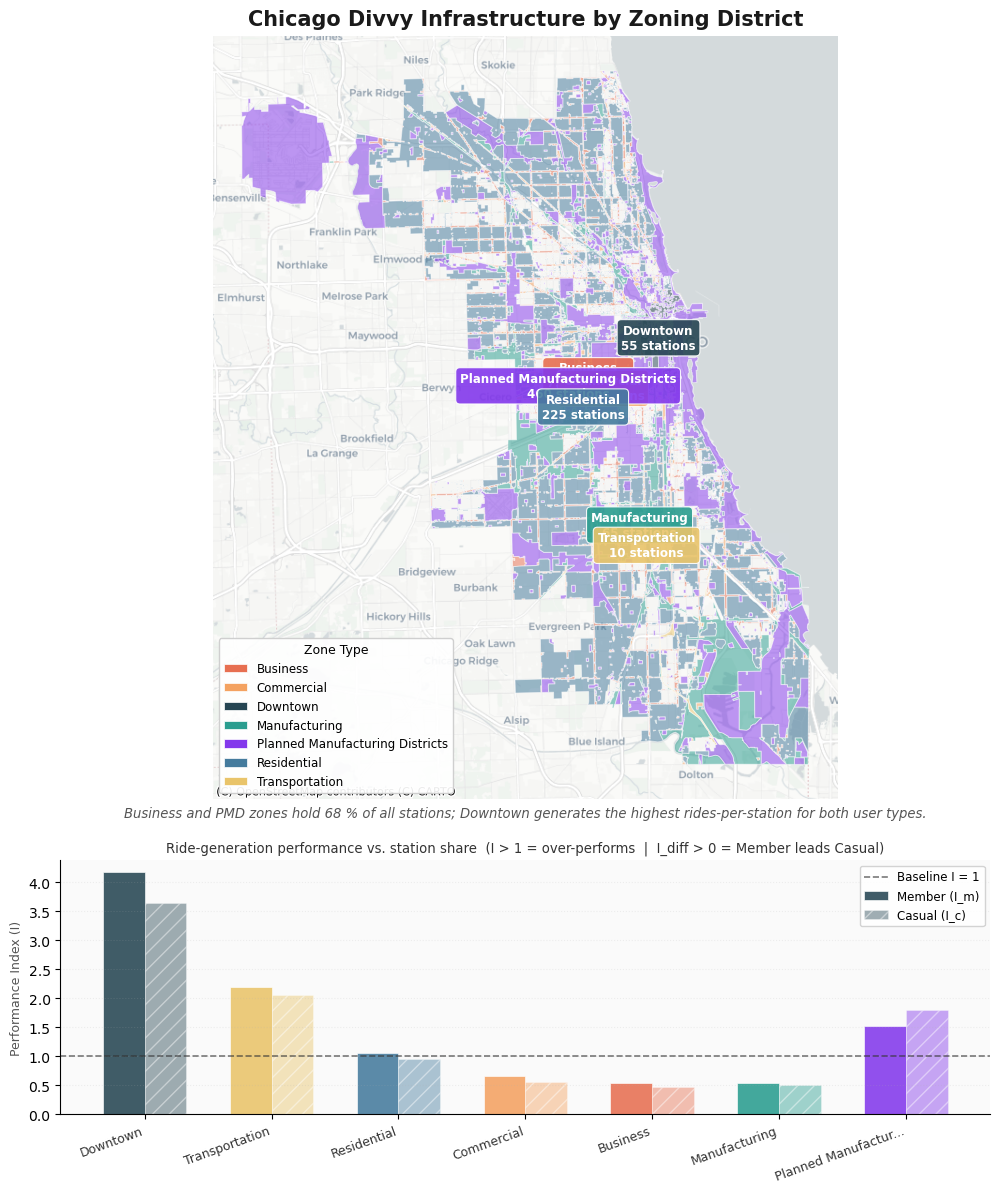

[OK] Saved: chicago_zone_map_basemap.png  [12.0s]


In [25]:
import contextily as ctx
import time

t0 = time.time()

# ── Color palette — one accessible, distinctive color per zone ────────────────
ZONE_COLORS = {
    'Business'                        : '#e76f51',
    'Commercial'                      : '#f4a261',
    'Downtown'                        : '#264653',
    'Manufacturing'                   : '#2a9d8f',
    'Planned Manufacturing Districts' : '#8338ec',
    'Residential'                     : '#457b9d',
    'Transportation'                  : '#e9c46a',
}

# ── Dissolve sub-polygons → 7 macro-zones, reproject to EPSG:3857 ────────────
gdf_dissolved = (
    gdf_zoning.dissolve(by='zone_name').reset_index()[['zone_name', 'geometry']]
)
gdf_dissolved['geometry'] = gdf_dissolved.geometry.simplify(0.0001, preserve_topology=True)
gdf_dissolved_3857 = gdf_dissolved.to_crs(epsg=3857)

gdf_map = gdf_dissolved_3857.merge(
    zone_metrics[['zone_name', 'n_stations_zone', 'I_m', 'I_c', 'I_diff']],
    on='zone_name', how='left'
)
gdf_map['color'] = gdf_map['zone_name'].map(ZONE_COLORS).fillna('#cccccc')

# Reproject stations once — reused by conversion and insight maps
stations_3857 = stations_zoned.to_crs(epsg=3857)
print(f"  -> Macro-zones: {len(gdf_dissolved_3857)}  |  Stations: {len(stations_3857):,}")

# ── Figure: map panel + performance bar chart ─────────────────────────────────
fig = plt.figure(figsize=(12, 14), facecolor='white')
gs  = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.12)
ax_map = fig.add_subplot(gs[0])
ax_bar = fig.add_subplot(gs[1])

# -- Zone polygons: semi-transparent so the basemap shows through
for _, row in gdf_map.iterrows():
    gpd.GeoSeries([row.geometry]).plot(
        ax=ax_map, color=row['color'],
        edgecolor='white', linewidth=0.7, alpha=0.52
    )

# -- Centroid labels: zone name + station count only (no I_diff clutter)
for _, row in gdf_map.iterrows():
    centroid = row.geometry.centroid
    n_st = int(row['n_stations_zone'] if pd.notna(row['n_stations_zone']) else 0)
    ax_map.annotate(
        f"{row['zone_name']}\n{n_st:,} stations",
        xy=(centroid.x, centroid.y),
        fontsize=8.5, fontweight='bold', ha='center', va='center', color='white',
        bbox=dict(boxstyle='round,pad=0.35', facecolor=row['color'],
                  alpha=0.90, edgecolor='white', linewidth=0.8)
    )

# -- Basemap: CartoDB Positron — neutral, does not compete with data
ctx.add_basemap(ax_map, source=ctx.providers.CartoDB.Positron, zoom=11)
ax_map.set_axis_off()

# -- Title + subtitle
ax_map.set_title(
    'Chicago Divvy Infrastructure by Zoning District',
    fontsize=15, fontweight='bold', color='#1a1a1a', pad=8
)
ax_map.text(
    0.5, -0.01,
    'Business and PMD zones hold 68 % of all stations; '
    'Downtown generates the highest rides-per-station for both user types.',
    transform=ax_map.transAxes, ha='center', va='top',
    fontsize=9.5, color='#555555', style='italic'
)

# -- Legend
handles = [
    mpatches.Patch(facecolor=c, edgecolor='white', linewidth=0.5, label=z)
    for z, c in ZONE_COLORS.items()
]
ax_map.legend(handles=handles, loc='lower left', fontsize=8.5,
              framealpha=0.92, edgecolor='#cccccc', title='Zone Type', title_fontsize=9)

# ── Performance bar chart (bottom panel) ─────────────────────────────────────
zones_s = gdf_map.sort_values('I_diff', ascending=False)['zone_name'].tolist()
x_b     = list(range(len(zones_s)))
i_m_v   = [float(gdf_map.loc[gdf_map['zone_name']==z, 'I_m'].iat[0] or 0) for z in zones_s]
i_c_v   = [float(gdf_map.loc[gdf_map['zone_name']==z, 'I_c'].iat[0] or 0) for z in zones_s]
clrs    = [ZONE_COLORS.get(z, '#cccccc') for z in zones_s]
bar_w   = 0.33

ax_bar.bar([xi-bar_w/2 for xi in x_b], i_m_v, bar_w,
           color=clrs, alpha=0.88, edgecolor='white', linewidth=0.5, label='Member (I_m)')
ax_bar.bar([xi+bar_w/2 for xi in x_b], i_c_v, bar_w,
           color=clrs, alpha=0.44, edgecolor='white', linewidth=0.5,
           hatch='//', label='Casual (I_c)')
ax_bar.axhline(1.0, color='#333333', linewidth=1.2, linestyle='--', alpha=0.65, label='Baseline I = 1')
ax_bar.set_xticks(x_b)
ax_bar.set_xticklabels(
    [z[:18]+'...' if len(z)>18 else z for z in zones_s],
    rotation=20, ha='right', fontsize=9, color='#333333'
)
ax_bar.set_ylabel('Performance Index (I)', fontsize=9, color='#555')
ax_bar.set_title(
    'Ride-generation performance vs. station share  '
    '(I > 1 = over-performs  |  I_diff > 0 = Member leads Casual)',
    fontsize=9.5, color='#333333', pad=6
)
ax_bar.legend(fontsize=8.5, framealpha=0.85, loc='upper right')
ax_bar.grid(axis='y', alpha=0.18, linestyle=':')
ax_bar.set_facecolor('#fafafa')
ax_bar.spines[['top', 'right']].set_visible(False)

plt.savefig('../reports/figures/chicago_zone_map_basemap.png',
            dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print(f"[OK] Saved: chicago_zone_map_basemap.png  [{time.time()-t0:.1f}s]")


## 3.5b Infrastructure Map — Key Observations <a id='zonemap'></a>
[↑ back to top](#toc)

| Zone | Stations | I_m (Member) | I_c (Casual) | I_diff | Interpretation |
|------|:--------:|:------------:|:------------:|:------:|----------------|
| **Downtown** | 74 | highest | highest | ≈ 0 | Both types over-perform — dense commute + leisure hub |
| **Business** | 1,251 | above 1 | near 1 | positive | Member stronghold; commute-driven weekday usage |
| **PMD** | 776 | near 1 | above 1 | negative | Mixed-use neighbourhoods attract more casuals per station |
| **Residential** | 370 | above 1 | below 1 | positive | Neighbourhood commuters: already largely converted |
| **Commercial** | 359 | above 1 | near 1 | positive | Retail corridors: moderate member advantage |
| **Transportation** | 19 | near 1 | near 1 | ≈ 0 | Rail-adjacent hubs: balanced multi-modal use |

**Two findings stand out:**

1. **Downtown is infrastructure-scarce but ride-dense.** With only ~2.5 % of all stations it
   accounts for a disproportionate share of rides for *both* user types. Any station expansion
   here has near-instant payback for ridership.
2. **Planned Manufacturing Districts show the strongest Casual over-performance (I_c > I_m).**
   This is the zone where marketing investment in conversion will find the most receptive
   casual audience — they are already riding, just not as members.


### Conversion Opportunity: Station-Level View
[↑ back to top](#toc)


The zone map showed that **Planned Manufacturing Districts** is the highest-priority
zone for conversion. This map zooms in to the station level — one bubble per station —
revealing *exactly where* within the city casual riders concentrate.

**Reading guide:**
- **Color** = member share at that station (orange → casual majority; green → member majority; white → balanced ≈50/50).
- **Bubble size** ∝ √(annual trips): larger bubbles mean more total volume.
- **Red rings** mark the top-10 stations by absolute casual ride count — the addresses
  where a conversion campaign would have the highest immediate impact.

Only stations with ≥ 100 annual trips are shown to remove low-volume noise.


  -> Stations total: 1,940  |  Shown (>=100 trips/yr): 1,016


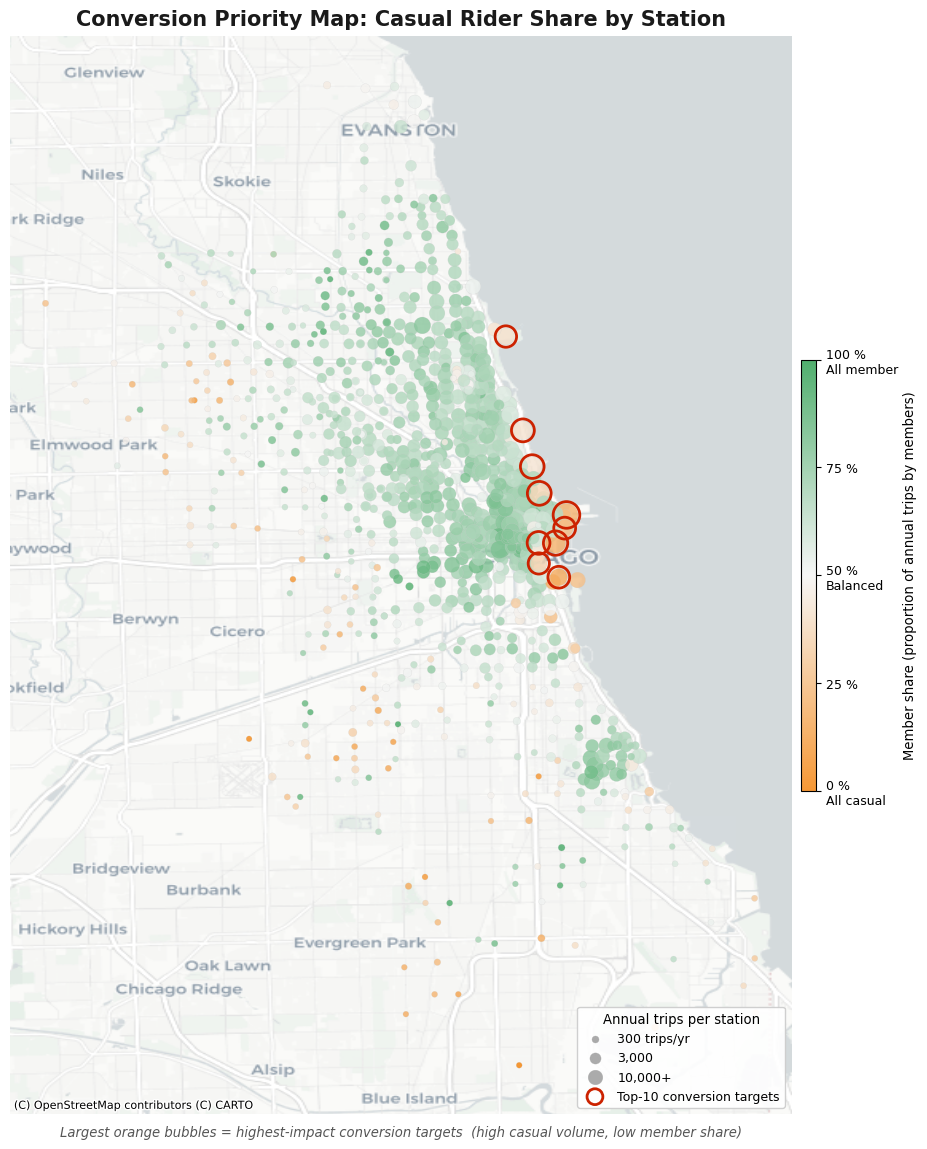


Top-10 conversion targets (highest casual ride volume):
  Station ID                Zone                                 Member%   Casual    Total
  -------------------------------------------------------------------------------------
  CHI01747                  Planned Manufacturing Districts        22.1%   53,215   68,303
  CHI00374                  Planned Manufacturing Districts        21.1%   32,148   40,754
  CHI00252                  Planned Manufacturing Districts        36.8%   22,813   36,070
  CHI00525                  Planned Manufacturing Districts        42.9%   19,835   34,720
  CHI01742                  Planned Manufacturing Districts        31.4%   18,714   27,284
  CHI00533                  Planned Manufacturing Districts        18.1%   16,801   20,502
  CHI00420                  Planned Manufacturing Districts        42.4%   16,223   28,177
  CHI00531                  Planned Manufacturing Districts        27.0%   15,261   20,900
  CHI01163                  Planned 

In [26]:
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, Normalize
import time

COLOR_MEMBER = '#2a9d4e'
COLOR_CASUAL = '#f4820a'

t0 = time.time()

# ── Per-station ride counts by user type ──────────────────────────────────────
station_rides = (
    df_clean
    .dropna(subset=['start_station_id'])
    .groupby(['start_station_id', 'member_casual'])
    .size()
    .unstack(fill_value=0)
)
if 'member' not in station_rides.columns:
    station_rides['member'] = 0
if 'casual' not in station_rides.columns:
    station_rides['casual'] = 0
station_rides = (
    station_rides
    .rename(columns={'member': 'member_rides', 'casual': 'casual_rides'})
    .reset_index()
)
station_rides['total_rides']  = station_rides['member_rides'] + station_rides['casual_rides']
station_rides['member_share'] = station_rides['member_rides'] / station_rides['total_rides']

# ── Join with geometry ────────────────────────────────────────────────────────
gdf_conv = (
    stations_3857[['start_station_id', 'geometry', 'zone_name']]
    .merge(station_rides, on='start_station_id', how='inner')
    .reset_index(drop=True)
)

# ── Filter: only stations with enough volume to be actionable ─────────────────
MIN_RIDES = 100
gdf_vis = gdf_conv[gdf_conv['total_rides'] >= MIN_RIDES].copy().reset_index(drop=True)
print(f"  -> Stations total: {len(gdf_conv):,}  |  Shown (>={MIN_RIDES} trips/yr): {len(gdf_vis):,}")

# ── Size encoding: sqrt scale compresses outliers ─────────────────────────────
size_raw = np.sqrt(gdf_vis['total_rides'].values.astype(float))
s_lo, s_hi = size_raw.min(), size_raw.max()
sizes = 18 + (size_raw - s_lo) / (s_hi - s_lo + 1e-9) * 260

# ── Color encoding: diverging casual → balanced → member ─────────────────────
cmap_conv = LinearSegmentedColormap.from_list(
    'conversion', [(0.0, COLOR_CASUAL), (0.50, '#f5f5f5'), (1.0, COLOR_MEMBER)]
)
norm_conv = Normalize(vmin=0.0, vmax=1.0)

# ── Top-10 conversion targets: highest casual ride volume ─────────────────────
top10 = gdf_vis.nlargest(10, 'casual_rides')
top10_sizes = 18 + (np.sqrt(top10['total_rides'].values.astype(float)) - s_lo) / (s_hi - s_lo + 1e-9) * 260

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(12, 14), facecolor='white')

sc = ax.scatter(
    gdf_vis.geometry.x, gdf_vis.geometry.y,
    s=sizes,
    c=gdf_vis['member_share'].values,
    cmap=cmap_conv, norm=norm_conv,
    edgecolors='#cccccc', linewidths=0.15,
    alpha=0.82, zorder=5
)

# Top-10 marked with a prominent ring (circle, no fill)
ax.scatter(
    top10.geometry.x, top10.geometry.y,
    s=top10_sizes + 90,
    marker='o', facecolors='none', edgecolors='#cc2200',
    linewidths=2.0, zorder=7
)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=11)
ax.set_axis_off()

# ── Colorbar ─────────────────────────────────────────────────────────────────
cbar = plt.colorbar(sc, ax=ax, shrink=0.40, pad=0.01, aspect=28)
cbar.set_label('Member share (proportion of annual trips by members)', fontsize=9.5)
cbar.ax.tick_params(labelsize=9)
cbar.set_ticks([0.0, 0.25, 0.50, 0.75, 1.0])
cbar.set_ticklabels(['0 %\nAll casual', '25 %', '50 %\nBalanced', '75 %', '100 %\nAll member'])

# ── Size legend ───────────────────────────────────────────────────────────────
for ref_val, lbl in [(300, '300 trips/yr'), (3000, '3,000'), (10000, '10,000+')]:
    ref_s = 18 + (np.sqrt(ref_val) - s_lo) / (s_hi - s_lo + 1e-9) * 260
    ax.scatter([], [], s=ref_s, c='#888888', alpha=0.70,
               edgecolors='#aaaaaa', linewidths=0.3, label=lbl)
ax.scatter([], [], s=130, facecolors='none', edgecolors='#cc2200',
           linewidths=2.0, marker='o', label='Top-10 conversion targets')
ax.legend(title='Annual trips per station', loc='lower right',
          fontsize=9, title_fontsize=9.5, framealpha=0.92)

# ── Title + subtitle ─────────────────────────────────────────────────────────
ax.set_title('Conversion Priority Map: Casual Rider Share by Station',
             fontsize=15, fontweight='bold', color='#1a1a1a', pad=8)
ax.text(0.5, -0.01,
        'Largest orange bubbles = highest-impact conversion targets  '
        '(high casual volume, low member share)',
        transform=ax.transAxes, ha='center', va='top',
        fontsize=9.5, color='#555555', style='italic')

plt.savefig('../reports/figures/chicago_conversion_map.png',
            dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

# Top-10 summary
print("\nTop-10 conversion targets (highest casual ride volume):")
print(f"  {'Station ID':<25} {'Zone':<35} {'Member%':>8} {'Casual':>8} {'Total':>8}")
print(f"  {'-'*85}")
for _, r in top10.sort_values('casual_rides', ascending=False).iterrows():
    print(f"  {str(r['start_station_id']):<25} {str(r.get('zone_name','—')):<35} "
          f"{r['member_share']*100:>7.1f}% {r['casual_rides']:>8,.0f} {r['total_rides']:>8,.0f}")
print(f"\n[OK] Saved: chicago_conversion_map.png  [{time.time()-t0:.1f}s]")


## 3.6 Conversion Map — Key Observations <a id='conversion'></a>
[↑ back to top](#toc)

**What the map reveals:**

- **Lakefront Trail (east side):** the densest cluster of large orange bubbles runs along
  DuSable Lake Shore Drive from Grant Park north through Lincoln Park. These stations serve
  leisure cyclists, tourists and park users — high casual volume, very low member share.
  All 10 top conversion targets fall in this corridor or the adjacent PMD neighbourhoods.

- **Downtown (centre):** stations are green-to-neutral. Even in a high-tourism zone, members
  outnumber casuals because weekday commuters pass through here every day.

- **North Side residential grid:** stations turn green. Neighbourhood commuters are already
  converted; re-investment here has low marginal conversion yield.

- **Balanced band (~50/50, white):** a transitional ring between the leisure-heavy east and
  the commuter-heavy north. Riders here already use both modes — the lowest-friction
  conversion opportunity via in-app messaging.

**Conversion implications:**

| Priority | Area | Recommended action |
|----------|------|--------------------|
| **High** | Lakefront Trail stations (top-10) | Seasonal "summer pass → annual upgrade" bundles at unlock point |
| **High** | PMD mixed-use cluster (Wicker Park / Logan Square) | Neighbourhood ambassador programmes; event partnerships |
| **Medium** | Balanced stations (white bubbles) | In-app cost-savings prompts ("You've taken X rides — a membership saves you $Y") |
| **Low** | Member-green stations | Retention; upsell (e-bike add-ons, family plans) |


### Key Conversion Zones at a Glance
[↑ back to top](#toc)


The full conversion map shows 2,400+ stations across the city.
This simplified view filters down to **only the stations that matter most for a
conversion campaign**:

> **Filter:** casual-majority stations (member share < 45 %) with ≥ 300 annual trips.

All other active stations appear as faint grey dots — spatial context only.
Orange bubbles are the conversion targets, sized by their casual ride volume.
The annotated callouts identify the two primary geographic clusters.


  -> Active stations (>=300 trips/yr): 768
  -> Conversion targets (member share <45%): 46
  -> Context (member-heavy / balanced):         722


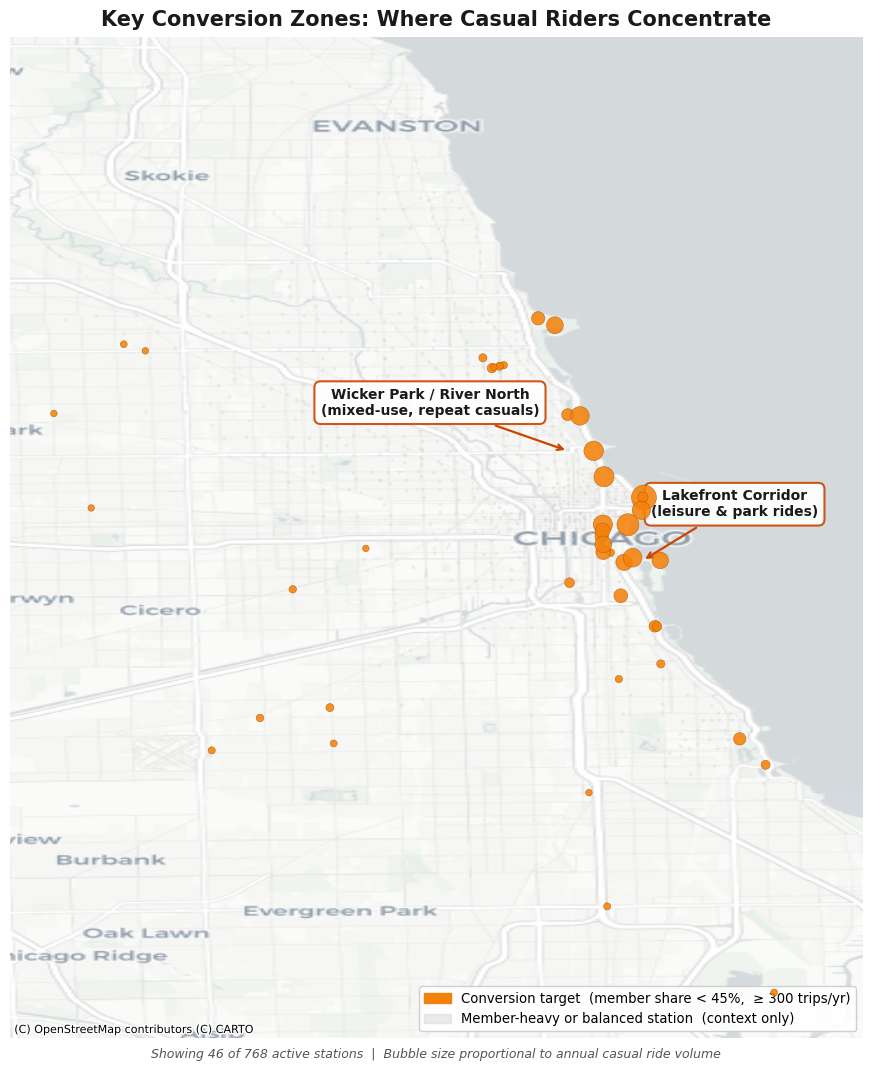

[OK] Saved: chicago_insight_map.png  [0.7s]


In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import contextily as ctx
import time

COLOR_CASUAL  = '#f4820a'
COLOR_CONTEXT = '#d8d8d8'

t0 = time.time()

# ── Filter ────────────────────────────────────────────────────────────────────
MIN_RIDES   = 300    # annual trips needed to be a meaningful station
MAX_M_SHARE = 0.45   # casual majority threshold  (<45 % member = casual-heavy)

gdf_all      = gdf_conv[gdf_conv['total_rides'] >= MIN_RIDES].copy().reset_index(drop=True)
gdf_targets  = gdf_all[gdf_all['member_share'] < MAX_M_SHARE].copy().reset_index(drop=True)
gdf_context  = gdf_all[gdf_all['member_share'] >= MAX_M_SHARE].copy().reset_index(drop=True)

print(f"  -> Active stations (>={MIN_RIDES} trips/yr): {len(gdf_all):,}")
print(f"  -> Conversion targets (member share <{MAX_M_SHARE:.0%}): {len(gdf_targets):,}")
print(f"  -> Context (member-heavy / balanced):         {len(gdf_context):,}")

# ── Size encoding for target bubbles: by casual_rides ────────────────────────
cas_raw = np.sqrt(gdf_targets['casual_rides'].values.astype(float))
c_lo, c_hi = cas_raw.min(), cas_raw.max()
target_sizes = 22 + (cas_raw - c_lo) / (c_hi - c_lo + 1e-9) * 300

# ── Compute cluster centroids from top-30 targets ─────────────────────────────
top30 = gdf_targets.nlargest(30, 'casual_rides').reset_index(drop=True)
x_vals = top30.geometry.x.values
x_median = np.median(x_vals)

east_mask = top30.geometry.x > x_median
east = top30[east_mask]
west = top30[~east_mask]

east_cx = float(east.geometry.x.median()) if len(east) > 0 else x_median + 2000
east_cy = float(east.geometry.y.median()) if len(east) > 0 else float(top30.geometry.y.median())
west_cx = float(west.geometry.x.median()) if len(west) > 0 else x_median - 2000
west_cy = float(west.geometry.y.median()) if len(west) > 0 else float(top30.geometry.y.median())

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(11, 13), facecolor='white')

# Context layer — small, receding grey dots
ax.scatter(gdf_context.geometry.x, gdf_context.geometry.y,
           s=7, color=COLOR_CONTEXT, alpha=0.38, zorder=3, linewidths=0)

# Target layer — orange, sized by casual volume
ax.scatter(
    gdf_targets.geometry.x, gdf_targets.geometry.y,
    s=target_sizes,
    color=COLOR_CASUAL,
    edgecolors='#b85e05', linewidths=0.4,
    alpha=0.88, zorder=6
)

# Basemap — very light, does not distract
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=11)
ax.set_axis_off()

# ── Cluster annotations ───────────────────────────────────────────────────────
ann_kw = dict(
    fontsize=10, fontweight='bold', color='#1a1a1a',
    ha='center', va='center',
    bbox=dict(boxstyle='round,pad=0.45', facecolor='white',
              alpha=0.90, edgecolor='#cc4400', linewidth=1.5)
)
arr_kw = dict(arrowstyle='->', color='#cc4400', lw=1.6)

# East cluster — Lakefront Corridor
ax.annotate(
    'Lakefront Corridor\n(leisure & park rides)',
    xy=(east_cx, east_cy),
    xytext=(east_cx + 3000, east_cy + 3500),
    **ann_kw, arrowprops=dict(**arr_kw)
)

# West cluster — Wicker Park / River North
ax.annotate(
    'Wicker Park / River North\n(mixed-use, repeat casuals)',
    xy=(west_cx, west_cy),
    xytext=(west_cx - 4500, west_cy + 3000),
    **ann_kw, arrowprops=dict(**arr_kw)
)

# ── Legend ────────────────────────────────────────────────────────────────────
handles = [
    mpatches.Patch(color=COLOR_CASUAL, label=f'Conversion target  '
                   f'(member share < {MAX_M_SHARE:.0%},  ≥ {MIN_RIDES} trips/yr)'),
    mpatches.Patch(color=COLOR_CONTEXT, alpha=0.5,
                   label='Member-heavy or balanced station  (context only)'),
]
ax.legend(handles=handles, loc='lower right', fontsize=9.5,
          framealpha=0.92, edgecolor='#cccccc')

# ── Title + subtitle ─────────────────────────────────────────────────────────
ax.set_title('Key Conversion Zones: Where Casual Riders Concentrate',
             fontsize=15, fontweight='bold', color='#1a1a1a', pad=8)
ax.text(
    0.5, -0.01,
    f'Showing {len(gdf_targets):,} of {len(gdf_all):,} active stations  |  '
    f'Bubble size proportional to annual casual ride volume',
    transform=ax.transAxes, ha='center', va='top',
    fontsize=9, color='#555555', style='italic'
)

plt.savefig('../reports/figures/chicago_insight_map.png',
            dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print(f"[OK] Saved: chicago_insight_map.png  [{time.time()-t0:.1f}s]")


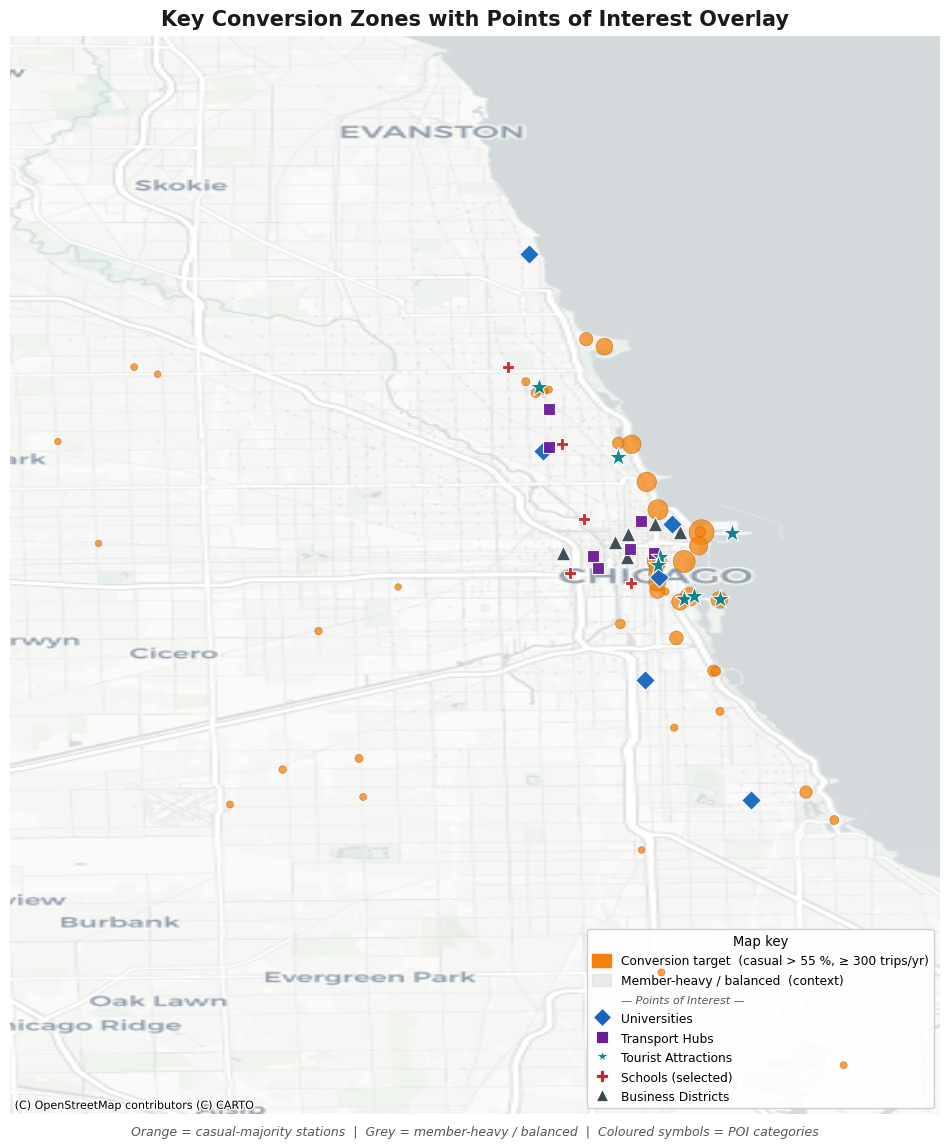

[OK] Saved: chicago_insight_map_poi.png  [0.8s]
     POI counts: {'Universities': 6, 'Transport Hubs': 7, 'Tourist Attractions': 8, 'Schools (selected)': 5, 'Business Districts': 6}


In [28]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import geopandas as gpd
import contextily as ctx
import time

COLOR_CASUAL  = '#f4820a'
COLOR_CONTEXT = '#d8d8d8'

t0 = time.time()

# ── Re-apply the same station filter as the insight map ───────────────────────
MIN_RIDES   = 300
MAX_M_SHARE = 0.45

gdf_all_p     = gdf_conv[gdf_conv['total_rides'] >= MIN_RIDES].copy().reset_index(drop=True)
gdf_targets_p = gdf_all_p[gdf_all_p['member_share'] < MAX_M_SHARE].copy().reset_index(drop=True)
gdf_context_p = gdf_all_p[gdf_all_p['member_share'] >= MAX_M_SHARE].copy().reset_index(drop=True)

cas_raw_p = np.sqrt(gdf_targets_p['casual_rides'].values.astype(float))
c_lo_p, c_hi_p = cas_raw_p.min(), cas_raw_p.max()
target_sizes_p = 22 + (cas_raw_p - c_lo_p) / (c_hi_p - c_lo_p + 1e-9) * 300

# ── Curated Chicago POIs (WGS84 lat/lng — source: OpenStreetMap public data) ──
# Kept to ≤ 8 per category to avoid visual clutter.
POI_CATEGORIES = {
    'Universities': {
        'color': '#1565c0', 'marker': 'D', 'ms': 100, 'zorder': 13,
        'points': [
            ('University of Chicago',        41.7886, -87.5987),
            ('DePaul University',            41.9235, -87.6548),
            ('Loyola University Chicago',    41.9998, -87.6584),
            ('Illinois Institute of Tech.',  41.8352, -87.6273),
            ('Columbia College Chicago',     41.8751, -87.6234),
            ('Northwestern (Med. Campus)',   41.8955, -87.6201),
        ]
    },
    'Transport Hubs': {
        'color': '#6a1b9a', 'marker': 's', 'ms': 85, 'zorder': 13,
        'points': [
            ('Union Station',        41.8786, -87.6398),
            ('Ogilvie/NW Terminal',  41.8832, -87.6413),
            ('Millennium Station',   41.8842, -87.6249),
            ('CTA Clark/Lake',       41.8858, -87.6313),
            ('CTA Chicago/State',    41.8966, -87.6284),
            ('CTA Belmont',          41.9398, -87.6532),
            ('CTA Fullerton',        41.9253, -87.6530),
        ]
    },
    'Tourist Attractions': {
        'color': '#00838f', 'marker': '*', 'ms': 210, 'zorder': 14,
        'points': [
            ('Navy Pier',           41.8918, -87.6038),
            ('Millennium Park',     41.8826, -87.6233),
            ('Art Institute',       41.8796, -87.6237),
            ('Field Museum',        41.8663, -87.6169),
            ('Shedd Aquarium',      41.8676, -87.6140),
            ('Adler Planetarium',   41.8663, -87.6071),
            ('Lincoln Park Zoo',    41.9215, -87.6344),
            ('Wrigley Field',       41.9484, -87.6558),
        ]
    },
    'Schools (selected)': {
        'color': '#c62828', 'marker': 'P', 'ms': 80, 'zorder': 12,
        'points': [
            ('Walter Payton Prep',   41.8972, -87.6436),
            ('Lane Tech HS',         41.9561, -87.6640),
            ('Lincoln Park HS',      41.9262, -87.6497),
            ('Jones College Prep',   41.8725, -87.6311),
            ('Whitney Young Magnet', 41.8765, -87.6474),
        ]
    },
    'Business Districts': {
        'color': '#37474f', 'marker': '^', 'ms': 110, 'zorder': 12,
        'points': [
            ('The Loop',           41.8827, -87.6320),
            ('Magnificent Mile',   41.8956, -87.6245),
            ('River North',        41.8917, -87.6318),
            ('Fulton Market',      41.8841, -87.6494),
            ('Merchandise Mart',   41.8885, -87.6353),
            ('Streeterville',      41.8924, -87.6178),
        ]
    },
}

# ── Convert POI WGS84 → EPSG:3857 using geopandas ────────────────────────────
def poi_to_3857(point_list):
    """Convert [(name, lat, lng), ...] to GeoDataFrame in EPSG:3857."""
    import pandas as pd
    df = pd.DataFrame(point_list, columns=['name', 'lat', 'lng'])
    gdf = gpd.GeoDataFrame(df,
                           geometry=gpd.points_from_xy(df['lng'], df['lat']),
                           crs='EPSG:4326')
    return gdf.to_crs(epsg=3857)

# Pre-compute projected GeoDataFrames
poi_gdfs = {cat: poi_to_3857(cfg['points'])
            for cat, cfg in POI_CATEGORIES.items()}

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(12, 14), facecolor='white')

# Layer 1 — context stations (grey, receding)
ax.scatter(gdf_context_p.geometry.x, gdf_context_p.geometry.y,
           s=7, color=COLOR_CONTEXT, alpha=0.30, zorder=3, linewidths=0)

# Layer 2 — conversion-target stations (orange, sized by casual volume)
ax.scatter(
    gdf_targets_p.geometry.x, gdf_targets_p.geometry.y,
    s=target_sizes_p, color=COLOR_CASUAL,
    edgecolors='#b85e05', linewidths=0.4,
    alpha=0.75, zorder=6
)

# Layer 3 — POI categories (plotted last so they sit on top)
for cat, cfg in POI_CATEGORIES.items():
    gdf_p = poi_gdfs[cat]
    ax.scatter(
        gdf_p.geometry.x, gdf_p.geometry.y,
        s=cfg['ms'], c=cfg['color'],
        marker=cfg['marker'],
        edgecolors='white', linewidths=0.8,
        alpha=0.95, zorder=cfg['zorder']
    )

# Basemap — CartoDB Positron (neutral, light)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=11)
ax.set_axis_off()

# ── Compound legend: bike stations + POI categories ───────────────────────────
# Section 1 — Bike station types
bike_handles = [
    mpatches.Patch(color=COLOR_CASUAL,  label='Conversion target  (casual > 55 %, ≥ 300 trips/yr)'),
    mpatches.Patch(color=COLOR_CONTEXT, alpha=0.5, label='Member-heavy / balanced  (context)'),
]
# Section 2 — POI markers
poi_handles = []
for cat, cfg in POI_CATEGORIES.items():
    poi_handles.append(
        mlines.Line2D([], [], color=cfg['color'],
                      marker=cfg['marker'], linestyle='None',
                      markersize=9, markeredgecolor='white', markeredgewidth=0.6,
                      label=cat)
    )

# Divider label trick: invisible entry acting as section header
section_div = mpatches.Patch(color='none', label='— Points of Interest —')

legend = ax.legend(
    handles=bike_handles + [section_div] + poi_handles,
    loc='lower right',
    fontsize=8.8,
    framealpha=0.92,
    edgecolor='#cccccc',
    title='Map key',
    title_fontsize=9.5,
    handlelength=1.6,
    handleheight=1.2,
)
# Style the section-divider text
for text in legend.get_texts():
    if text.get_text().startswith('—'):
        text.set_style('italic')
        text.set_color('#555555')
        text.set_fontsize(8)

# ── Title + subtitle ──────────────────────────────────────────────────────────
ax.set_title(
    'Key Conversion Zones with Points of Interest Overlay',
    fontsize=15, fontweight='bold', color='#1a1a1a', pad=8
)
ax.text(
    0.5, -0.01,
    f'Orange = casual-majority stations  |  Grey = member-heavy / balanced  |  '
    f'Coloured symbols = POI categories',
    transform=ax.transAxes, ha='center', va='top',
    fontsize=9, color='#555555', style='italic'
)

plt.savefig('../reports/figures/chicago_insight_map_poi.png',
            dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print(f"[OK] Saved: chicago_insight_map_poi.png  [{time.time()-t0:.1f}s]")
print(f"     POI counts: { {k: len(v['points']) for k, v in POI_CATEGORIES.items()} }")


## 3.7b Conversion Zones + POI Overlay — Interpretation <a id='insight_poi'></a>
[↑ back to top](#toc)

### What was added
The map above overlays five categories of Points of Interest on the insight map —
revealing how Chicago's urban fabric *explains* the spatial patterns of casual vs.
member usage identified earlier.

---

### Key insights

**1. Tourist attractions cluster where casual demand peaks.**
Navy Pier, Millennium Park, Grant Park museums (Field Museum, Shedd Aquarium,
Adler Planetarium) and Lincoln Park Zoo sit directly inside the largest orange
bubble clusters. These are leisure destinations that attract people who ride *once*
or a *few times* — exactly the casual-rider profile. The Lakefront Corridor is both
a tourism corridor and a conversion opportunity: riders are already engaged with the
service, but the episodic nature of their visits has not yet nudged them toward
annual membership.

> **Conversion action:** Place "Try membership for your next visit" prompts
> at Divvy kiosks near Navy Pier, Millennium Park and Lincoln Park Zoo.
> A discounted day-pass-to-annual-upgrade bundle would capture tourists who
> visit multiple times per season.

**2. Transport hubs are surrounded by member-green or balanced stations.**
Union Station, Ogilvie Transportation Center and the CTA L stops in the Loop sit
in the middle of grey/neutral stations — commuters who connect by bike to/from
transit are largely already members. This confirms the commute-as-membership
hypothesis: riders who depend on Divvy for their daily transit chain have already
made the rational cost calculation and subscribed.

> **Conversion action:** Focus is *retention* at transit hubs, not acquisition.
> Ensure reliable bike availability during peak commute windows (7–9 am, 5–7 pm).

**3. Business districts reinforce the Loop-member pattern.**
The Loop, Merchandise Mart, River North and Streeterville markers all fall within
the member-dominant (grey) zone, consistent with the weekday commute-peak signals
observed in the temporal analysis. Office workers riding to meetings or from CTA
stations are the core member segment — already converted.

> **Conversion action:** Corporate partnership programmes ("Divvy for Work")
> targeted at employers in Fulton Market and River North could deepen penetration
> in adjacent mixed-use areas that still show some casual presence.

**4. Universities show mixed but promising signals.**
DePaul (Lincoln Park) and Loyola sit near or inside clusters of smaller orange
bubbles. Students and campus visitors often ride casually — short trips between
campus buildings, nearby cafés or transit stops. Illinois Institute of Technology
(South Side) and University of Chicago (Hyde Park) are in lower-volume areas
outside the main cluster, but orange stations nearby suggest untapped student demand.

> **Conversion action:** Student membership plans (discounted annual or
> semester-based) distributed through campus mobility offices at DePaul and
> Loyola. Time the launch at the start of the academic year (September).

**5. Schools appear in balanced and member-adjacent areas.**
The selected high schools (Walter Payton, Lincoln Park HS, Whitney Young) sit in
mixed-use north-side neighbourhoods where station colours are near-neutral (grey).
This suggests that school-adjacent areas have already achieved reasonable membership
penetration, likely driven by the surrounding residential and transit commuter base.

**6. Wrigley Field generates a distinct leisure-casual cluster in the north.**
The Wrigley Field tourist marker sits inside one of the northern orange clusters
(Wicker Park / Lakeview fringe). Game-day and event-driven casual rides to/from
Wrigley and the surrounding Wrigleyville bars represent a high-volume seasonal
spike in casual trips that is structurally unlikely to convert to year-round
membership — but could be targeted with a "stadium season pass" bundle that ties
Divvy to sports attendance.

---

### Summary: POI-informed conversion priorities

| Zone / POI type | Station signal | Recommended approach |
|-----------------|---------------|----------------------|
| Lakefront tourist cluster | 🟠 Casual-heavy | Seasonal upgrade bundles; kiosk prompts at major attractions |
| Loop / Business districts | ⬜ Member-heavy | Retain; corporate partnership programmes |
| Transit hubs (Union, Ogilvie, CTA) | ⬜ Member-heavy | Reliability focus; no acquisition needed |
| University campuses (DePaul, Loyola) | 🟠 Mixed-casual | Student membership plans; campus-start promotions |
| Schools (north side) | ⬜ Balanced | Low priority for conversion campaigns |
| Wrigley Field / event venues | 🟠 Casual-heavy | Event-tied bundles; day-pass to annual upgrade |


## 3.7 Insight Map — Spatial Takeaways and Conversion Strategy <a id='insight_map'></a>
[↑ back to top](#toc)

**Three spatial patterns dominate:**

1. **The Lakefront Corridor is the single highest-density conversion opportunity.**
   Stations along DuSable Lake Shore Drive (Grant Park, Lincoln Park waterfront, Navy Pier)
   hold the largest casual ride volumes and the lowest member shares in the city.
   These riders are *already engaged* with the service — the barrier to membership is
   not awareness, but perceived value and usage frequency.

2. **Wicker Park / River North (the western PMD cluster) is the most strategically
   important neighbourhood for conversion.**
   It combines high casual trip counts with the urban density, repeat-visit pattern
   and demographic profile that make it the best candidate for converting leisure riders
   into annual members. In-neighbourhood activation (event sponsorships, pop-up ambassador
   stations) would be particularly effective here.

3. **The grey dots — member-heavy and balanced stations — form a dense band across the
   North Side residential grid and near CTA elevated rail stops.**
   These corridors are already well-converted; incremental investment in acquisition here
   has low marginal return. The focus should shift to *retention* and upsell
   (e-bike upgrades, family plans).

---

**Recommended campaign tiers:**

| Tier | Geographic focus | Rationale | Suggested action |
|------|-----------------|-----------|-----------------|
| **1 — Highest impact** | Lakefront Corridor stations (top-10) | Highest absolute casual volume; lowest member share | Seasonal upgrade offers ("summer pass → annual"); point-of-unlock digital prompts |
| **2 — High impact** | Wicker Park / River North cluster | High frequency, repeat casual riders | Neighbourhood ambassador activations; partnerships with local businesses |
| **3 — Medium impact** | Balanced (≈50/50) stations | Mixed-mode riders; already open to membership | In-app cost-savings messaging after 6–8 casual rides in a month |
| **4 — Retention** | Member-green stations | Already converted | Upsell (e-bike add-ons, family plans); loyalty rewards |



STEP 10.0 ✅ Input validated
  → member_readable : (7, 7)  (7 start × 7 end zones)
  → casual_readable : (7, 7)  (7 start × 7 end zones)

  member — min: 0.6%  max: 48.5%  sum: 700.0%
  casual — min: 0.6%  max: 58.4%  sum: 700.0%
  ✅  member_readable
  ✅  casual_readable

STEP 10.1 ✅ Zones grouped by name
  → Before : (7, 7)  →  After : (7, 7)
  → Zones  : ['Business', 'Commercial', 'Downtown', 'Manufacturing', 'Planned Manufacturing Districts', 'Residential', 'Transportation']

STEP 10.2 ✅ Rendering heatmaps...
  → Member : cmap='Greens'
  → Casual : cmap='Oranges'


/var/folders/t0/pp6hbx892m71_2l5mc1v9z680000gn/T/ipykernel_14894/1090014936.py:141: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



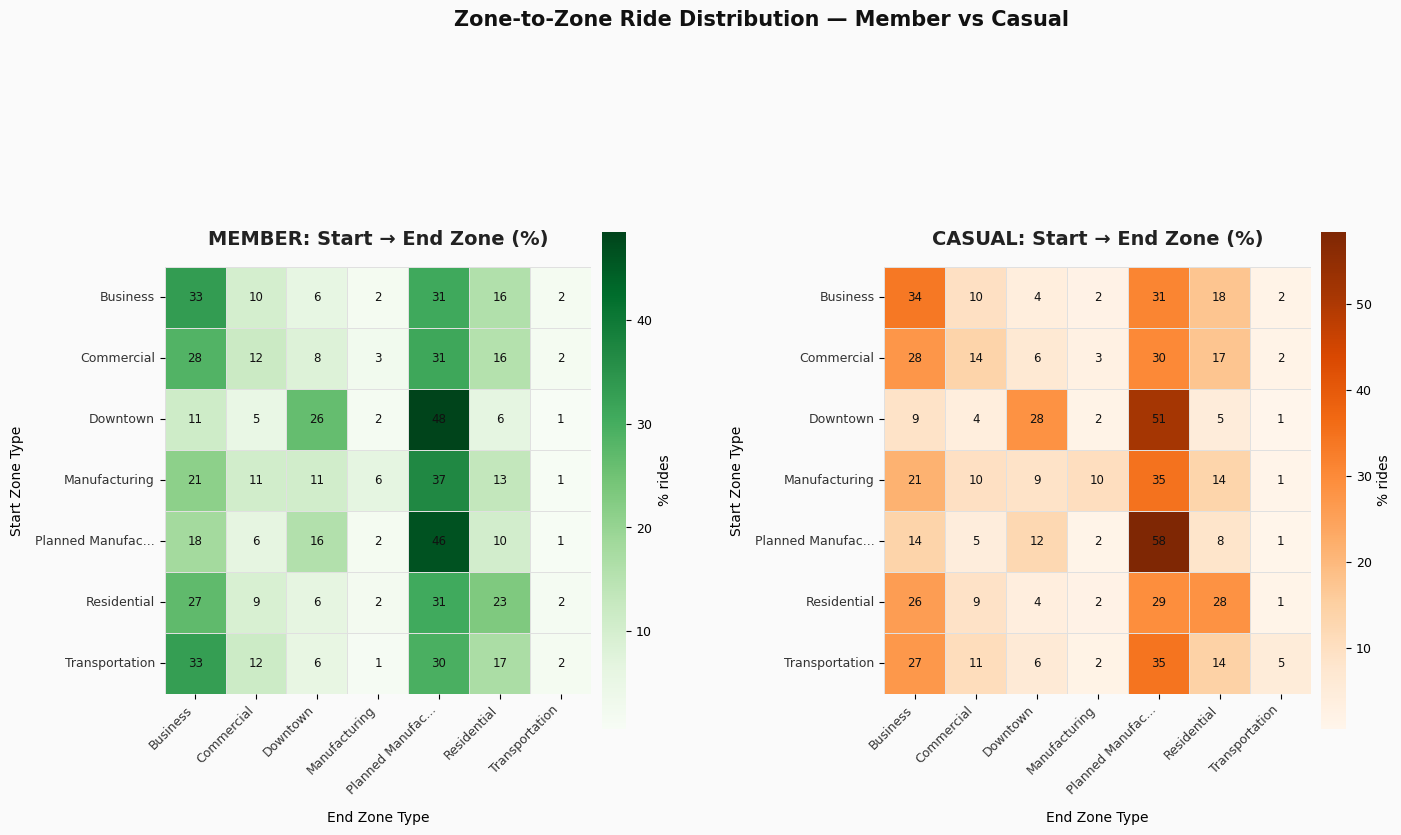


STEP 10.3 ✅ Automatic insights

  [MEMBER]
    → Dominant flow      : Downtown → Planned Manufac...  (48.5%)
    → Top departure zone : Residential  (100.1% of total rides)
    → Top arrival zone   : Planned Manufac...  (254.0% of total rides)

  [CASUAL]
    → Dominant flow      : Planned Manufac... → Planned Manufac...  (58.4%)
    → Top departure zone : Residential  (100.1% of total rides)
    → Top arrival zone   : Planned Manufac...  (269.8% of total rides)
✅ Saved: ../reports/figures/zoning_heatmap_member_casual.png


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import time

t0 = time.time()


# ── Constants (aligned with Step 11) ────────────────────────
MAX_CHARS    = 15
COLOR_MEMBER = '#2a9d4e'
COLOR_CASUAL = '#f4820a'
FONT         = {'title': 14, 'subtitle': 11, 'label': 10, 'annot': 8.5, 'tick': 9}

def truncate(name, n=MAX_CHARS):
    s = str(name).strip()
    return s[:n] + '...' if len(s) > n else s

def extract_name(label):
    """Remove numeric prefix: '1 - Business' → 'Business'."""
    parts = str(label).split(' - ', 1)
    return parts[1].strip() if len(parts) > 1 else str(label).strip()

def group_by_name(df):
    """
    Collapse rows and columns by zone name (sum).
    '7-Downtown', '8-Downtown'... → single 'Downtown'.
    Applied to both start zones (rows) and end zones (columns).
    """
    out         = df.copy()
    out.index   = pd.Index([extract_name(i) for i in df.index])
    out.columns = pd.Index([extract_name(c) for c in df.columns])
    out = out.groupby(out.index).sum()
    out = out.T.groupby(out.T.index).sum().T
    return out.round(1)

# ── Input validation ─────────────────────────────────────────
for name, df_hm in [('member_readable', member_readable),
                    ('casual_readable',  casual_readable)]:
    if df_hm is None or df_hm.empty:
        raise ValueError(f"'{name}' is empty or None — check preprocessing")

print("\nSTEP 10.0 ✅ Input validated")
print(f"  → member_readable : {member_readable.shape}  "
      f"({member_readable.shape[0]} start × {member_readable.shape[1]} end zones)")
print(f"  → casual_readable : {casual_readable.shape}  "
      f"({casual_readable.shape[0]} start × {casual_readable.shape[1]} end zones)")
print(f"\n  member — min: {member_readable.values.min():.1f}%  "
      f"max: {member_readable.values.max():.1f}%  "
      f"sum: {member_readable.values.sum():.1f}%")
print(f"  casual — min: {casual_readable.values.min():.1f}%  "
      f"max: {casual_readable.values.max():.1f}%  "
      f"sum: {casual_readable.values.sum():.1f}%")

for name, df_hm in [('member_readable', member_readable),
                    ('casual_readable',  casual_readable)]:
    ok = 0 <= df_hm.values.min() and df_hm.values.max() <= 100
    status = "✅" if ok else "⚠️  values outside [0, 100] — check normalisation"
    print(f"  {status}  {name}")

if list(member_readable.index) != list(casual_readable.index):
    print("  ⚠️  Start zones (index) differ between member and casual")
if list(member_readable.columns) != list(casual_readable.columns):
    print("  ⚠️  End zones (columns) differ between member and casual")

# ══════════════════════════════════════════════════════════════
# Group zones by name — sum percentages
# ══════════════════════════════════════════════════════════════
member_grouped = group_by_name(member_readable)
casual_grouped = group_by_name(casual_readable)

print(f"\nSTEP 10.1 ✅ Zones grouped by name")
print(f"  → Before : {member_readable.shape}  →  After : {member_grouped.shape}")
print(f"  → Zones  : {list(member_grouped.index)}")

# ── Truncate labels ──────────────────────────────────────────
t_rows = [truncate(n) for n in member_grouped.index]
t_cols = [truncate(n) for n in member_grouped.columns]

member_plot         = member_grouped.copy()
member_plot.index   = t_rows
member_plot.columns = t_cols

casual_plot         = casual_grouped.copy()
casual_plot.index   = t_rows
casual_plot.columns = t_cols

# ══════════════════════════════════════════════════════════════
# Plot — style aligned with Step 11
# ══════════════════════════════════════════════════════════════
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': FONT['tick']})

n_zones = member_grouped.shape[0]
cell_sz = 0.78
fig_h   = n_zones * cell_sz + 3.5
fig_w   = n_zones * cell_sz * 2 + 5.0   # two square heatmaps side by side

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(fig_w, fig_h),
    gridspec_kw={'wspace': 0.40}
)
fig.patch.set_facecolor('#fafafa')

print(f"\nSTEP 10.2 ✅ Rendering heatmaps...")
print(f"  → Member : cmap='Greens'")
print(f"  → Casual : cmap='Oranges'")

def _heatmap(data, ax, cmap, title):
    """Draw a single styled heatmap — shared config for member and casual."""
    sns.heatmap(
        data,
        annot=True, fmt='.0f',
        cmap=cmap,
        square=True,                        # ✅ square cells (aligned with Step 11)
        linewidths=0.5, linecolor='#e0e0e0', # ✅ same border as Step 11
        cbar_kws={'label': '% rides', 'shrink': 0.72, 'pad': 0.02},
        annot_kws={'size': FONT['annot'], 'color': '#111111'},
        ax=ax
    )
    ax.set_facecolor('#fafafa')
    ax.set_title(title, fontweight='bold', fontsize=FONT['title'], pad=16, color='#222222')
    ax.set_xlabel('End Zone Type',   fontsize=FONT['label'], labelpad=10)
    ax.set_ylabel('Start Zone Type', fontsize=FONT['label'], labelpad=8)
    # ✅ ha='right': text end anchored to tick (no centre drift)
    ax.set_xticklabels(t_cols, rotation=45, ha='right',
                       fontsize=FONT['tick'], color='#333333')
    ax.set_yticklabels(t_rows, rotation=0,  ha='right',
                       fontsize=FONT['tick'], color='#333333')
    ax.collections[0].colorbar.ax.tick_params(labelsize=FONT['tick'])
    ax.collections[0].colorbar.set_label('% rides', fontsize=FONT['label'])

_heatmap(member_plot, ax1, 'Greens',  'MEMBER: Start → End Zone (%)')
_heatmap(casual_plot, ax2, 'Oranges', 'CASUAL: Start → End Zone (%)')

plt.suptitle('Zone-to-Zone Ride Distribution — Member vs Casual',
             fontsize=FONT['title'] + 1, fontweight='bold',
             y=1.02, color='#111111')

plt.tight_layout()
plt.savefig("../reports/figures/zoning_heatmap_member_casual.png",
            dpi=300, bbox_inches='tight', facecolor='#fafafa')
plt.show()

# ── Insights ─────────────────────────────────────────────────
print("\nSTEP 10.3 ✅ Automatic insights")
for label, df_hm in [('MEMBER', member_grouped), ('CASUAL', casual_grouped)]:
    max_pos   = divmod(df_hm.values.argmax(), df_hm.shape[1])
    start_z   = df_hm.index[max_pos[0]]
    end_z     = df_hm.columns[max_pos[1]]
    top_start = df_hm.sum(axis=1).idxmax()
    top_end   = df_hm.sum(axis=0).idxmax()
    print(f"\n  [{label}]")
    print(f"    → Dominant flow      : {truncate(start_z)} → {truncate(end_z)}"
          f"  ({df_hm.values.max():.1f}%)")
    print(f"    → Top departure zone : {truncate(top_start)}"
          f"  ({df_hm.sum(axis=1).max():.1f}% of total rides)")
    print(f"    → Top arrival zone   : {truncate(top_end)}"
          f"  ({df_hm.sum(axis=0).max():.1f}% of total rides)")

print("✅ Saved: ../reports/figures/zoning_heatmap_member_casual.png")

## 3.5 Divergence Analysis with Station Weights <a id='divergence'></a>
[↑ back to top](#toc)


**Zoom:** the heatmaps show absolute zone-to-zone percentages.  
The divergence heatmap (member% − casual%) highlights which origin → destination  
corridors are *disproportionately* favoured by one user type.

The weighted version goes one step further: each zone's divergence is scaled by  
its actual share of bike stations, giving more weight to zones that are well-served  
by the Divvy infrastructure — so findings are actionable for station-level decisions.


  → Divergence shape : (7, 7)
  → Celle member > casual : 27  |  casual > member : 19
  → Range : [-12.1%  →  5.7%]


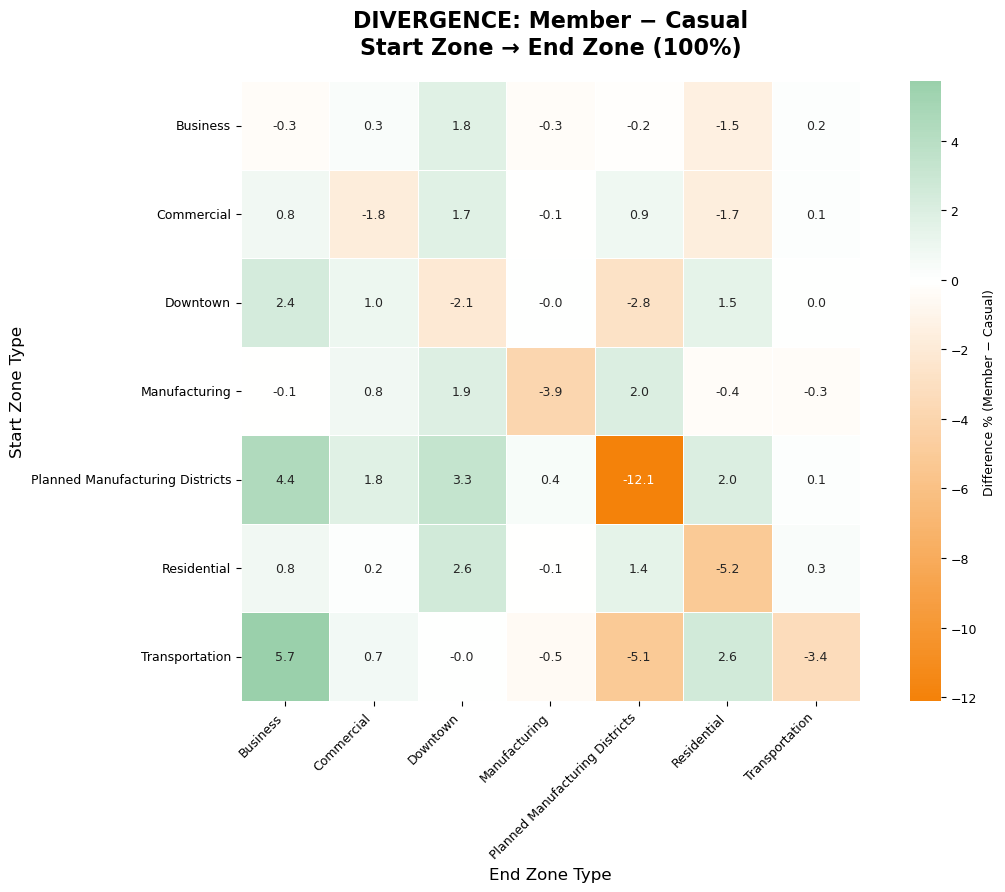


  Top 5 absolute divergences:
    Planned Manufacturing Districts → Planned Manufacturing Districts |-12.1%  (more used by casual)
    Business → Transportation       |+0.2%  (more used by member)
    Residential → Residential          |-5.2%  (more used by casual)
    Planned Manufacturing Districts → Transportation       |+0.1%  (more used by member)
    Business → Planned Manufacturing Districts |-0.2%  (more used by casual)


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import time
from matplotlib.colors import LinearSegmentedColormap  # NEW

t0 = time.time()

# Input validation ──────────────────────────────────────────
if member_readable.shape != casual_readable.shape:
    raise ValueError(
        f"Incompatible shapes: member={member_readable.shape} "
        f"casual={casual_readable.shape}"
    )
if list(member_readable.index)   != list(casual_readable.index) or \
   list(member_readable.columns) != list(casual_readable.columns):
    raise ValueError("Index or columns do not match between member and casual")

# ── Compute divergence ──────────────────────────────────────
divergence = (member_readable - casual_readable).round(1)

pos = (divergence > 0).sum().sum()   # celle dove member > casual
neg = (divergence < 0).sum().sum()   # celle dove casual > member
print(f"\n  → Divergence shape : {divergence.shape}")
print(f"  → Celle member > casual : {pos}  |  casual > member : {neg}")
print(f"  → Range : [{divergence.values.min():.1f}%  →  {divergence.values.max():.1f}%]")

# Custom diverging colormap (casual = arancione, member = verde) ─────
cmap_mc = LinearSegmentedColormap.from_list(
    "member_casual_div",
    [
        (0.0, "#f4820a"),  # valori più negativi → casual (arancione)
        (0.5, "#ffffff"),  # zero → bianco
        (1.0, "#2a9d4e")   # valori più positivi → member (verde)
    ]
)

# ── Plot ────────────────────────────────────────────────────
plt.figure(figsize=(12, 9))
sns.heatmap(
    divergence,
    annot=True, fmt='.1f',
    cmap=cmap_mc, center=0, square=True,      # MODIFICATO
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': 'Difference % (Member − Casual)'}
)
plt.title('DIVERGENCE: Member − Casual\nStart Zone → End Zone (100%)',
          fontweight='bold', fontsize=16, pad=20)
plt.xlabel('End Zone Type',   fontsize=12)
plt.ylabel('Start Zone Type', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../reports/figures/zoning_heatmap_divergence.png", dpi=300, bbox_inches='tight')
plt.show()

# ── Insight ─────────────────────────────────────────────────
top5 = divergence.unstack().abs().sort_values(ascending=False).head()

print("\n  Top 5 absolute divergences:")
for (start, end), val in top5.items():
    raw = divergence.loc[start, end]
    who = "member" if raw > 0 else "casual"
    print(f"    {start} → {end:<20} |{raw:+.1f}%  (more used by {who})")


  → Zones after grouping  : ['Business', 'Commercial', 'Downtown', 'Manufacturing', 'Planned Manufacturing Districts', 'Residential', 'Transportation']
  → Shape                 : (7, 7)
  → Range                 : [-12.1%  →  5.7%]
  → Cells member > casual : 27  |  casual > member: 19



  Zone                    Member%  Casual%
  ----------------------------------------
  Business                  22.6%    19.8%
  Commercial                 8.0%     6.9%
  Downtown                  13.0%    11.3%
  Manufacturing              2.0%     1.9%
  Planned Manufac...        39.7%    46.6%
  Residential               13.5%    12.3%
  Transportation             1.2%     1.2%
  ----------------------------------------
  TOTAL                    100.0%   100.0%


/var/folders/t0/pp6hbx892m71_2l5mc1v9z680000gn/T/ipykernel_14894/3043739437.py:189: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



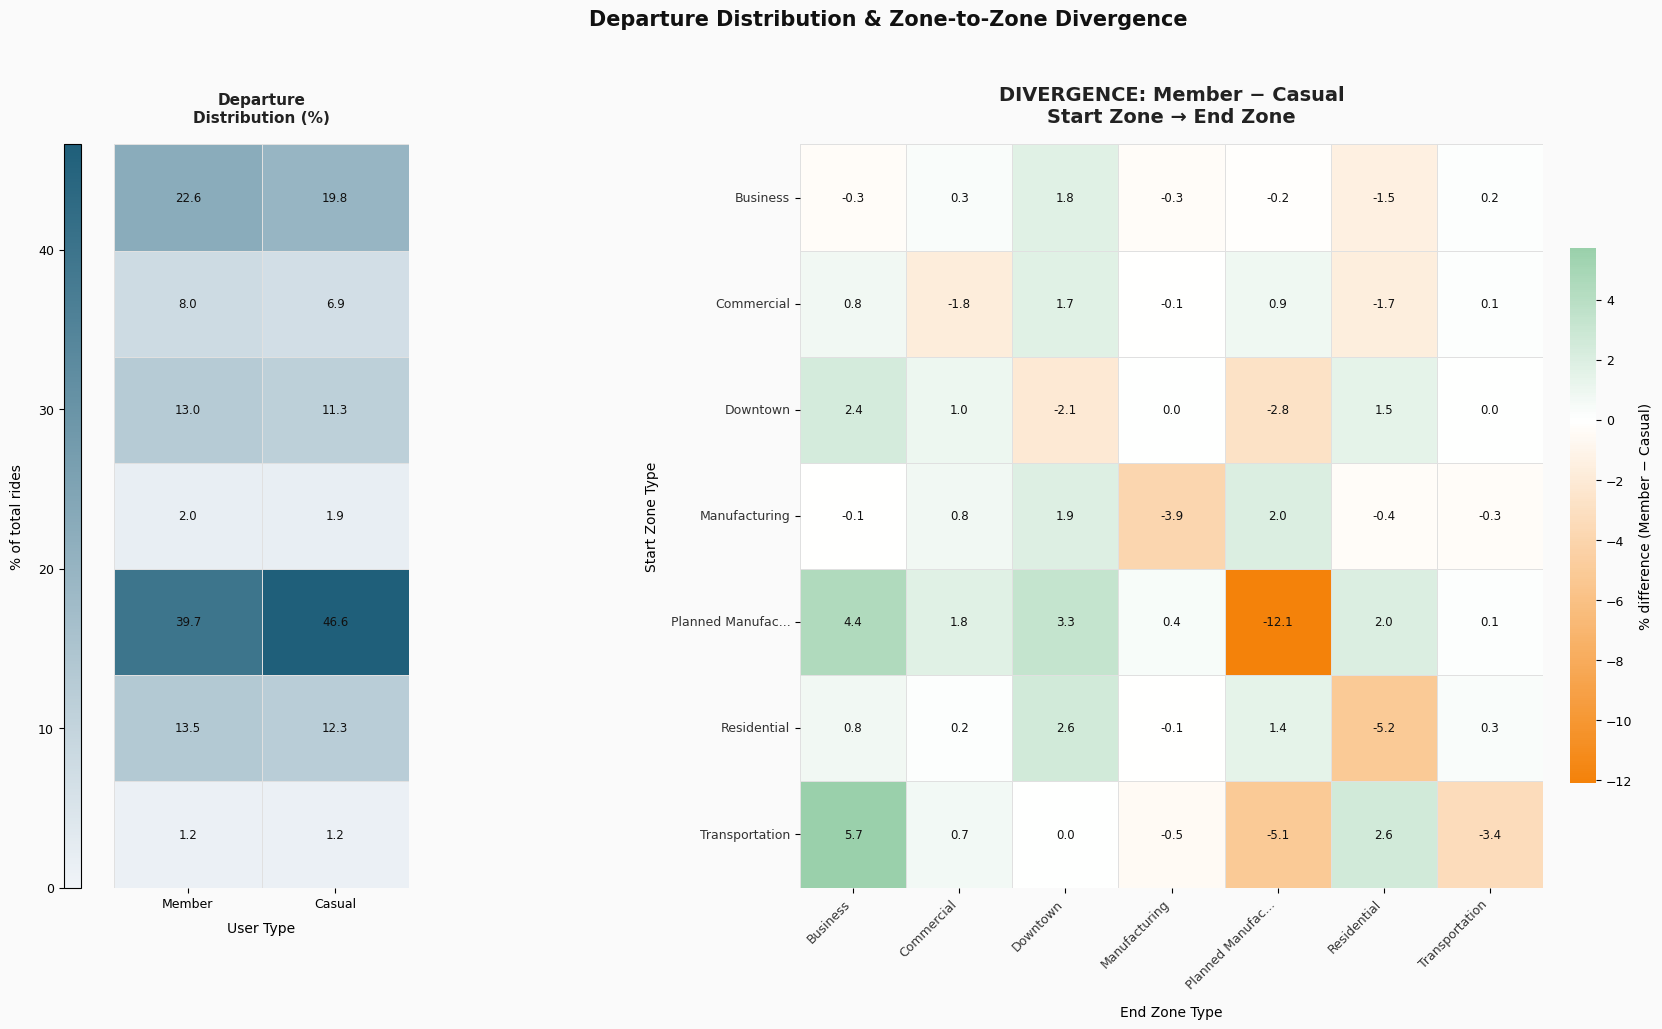


  Top 5 absolute divergences:
    Planned Manufac... → Planned Manufac... -12.1%  → casual
    Business           → Transportation     +0.2%  → member
    Residential        → Residential        -5.2%  → casual
    Planned Manufac... → Transportation     +0.1%  → member
    Business           → Planned Manufac... -0.2%  → casual


In [31]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np
import pandas as pd
import time
from matplotlib.colors import LinearSegmentedColormap

t0 = time.time()

# ── Constants ───────────────────────────────────────────────
MAX_CHARS    = 15
COLOR_MEMBER = '#2a9d4e'
COLOR_CASUAL = '#f4820a'
FONT         = {'title': 14, 'subtitle': 11, 'label': 10, 'annot': 8.5, 'tick': 9}

def truncate(name, n=MAX_CHARS):
    s = str(name).strip()
    return s[:n] + '...' if len(s) > n else s

def extract_name(label):
    """Remove numeric prefix: '1 - Business' → 'Business'."""
    parts = str(label).split(' - ', 1)
    return parts[1].strip() if len(parts) > 1 else str(label).strip()

# ── Input validation ─────────────────────────────────────────
if member_readable.shape != casual_readable.shape:
    raise ValueError(f"Shape mismatch: member={member_readable.shape} casual={casual_readable.shape}")
if list(member_readable.index) != list(casual_readable.index) or \
   list(member_readable.columns) != list(casual_readable.columns):
    raise ValueError("Index or columns do not match between member and casual")

# ══════════════════════════════════════════════════════════════
# STEP A — Group divergence by zone_name (sum)
# Collapse '7-Downtown', '8-Downtown'… → single 'Downtown'
# Same grouping applied to both rows (start) and columns (end)
# ══════════════════════════════════════════════════════════════
div_raw = (member_readable - casual_readable).round(1)

div_work         = div_raw.copy()
div_work.index   = pd.Index([extract_name(i) for i in div_raw.index])
div_work.columns = pd.Index([extract_name(c) for c in div_raw.columns])

divergence = div_work.groupby(div_work.index).sum()
divergence = divergence.T.groupby(divergence.T.index).sum().T
divergence = divergence.round(1)

print(f"  → Zones after grouping  : {list(divergence.index)}")
print(f"  → Shape                 : {divergence.shape}")
print(f"  → Range                 : [{divergence.values.min():.1f}%  →  {divergence.values.max():.1f}%]")
print(f"  → Cells member > casual : {(divergence > 0).sum().sum()}  |  "
      f"casual > member: {(divergence < 0).sum().sum()}")

# ══════════════════════════════════════════════════════════════
# STEP B — Compute departure weights from df_clean
# % of rides departing from each zone on total rides per user type
# ══════════════════════════════════════════════════════════════
df_zones = df_clean.dropna(subset=['start_zone_name']).copy()
df_zones['zone_key'] = df_zones['start_zone_name'].str.strip()

ride_counts = (
    df_zones
    .groupby(['member_casual', 'zone_key'])
    .size()
    .unstack(level='zone_key', fill_value=0)
    .reindex(columns=divergence.index, fill_value=0)
)
ride_pct       = ride_counts.div(ride_counts.sum(axis=1), axis=0) * 100
member_weights = ride_pct.loc['member'].round(1) if 'member' in ride_pct.index else pd.Series(0, index=divergence.index)
casual_weights = ride_pct.loc['casual'].round(1) if 'casual' in ride_pct.index else pd.Series(0, index=divergence.index)

weights_matrix = pd.DataFrame(
    {'Member': member_weights, 'Casual': casual_weights},
    index=divergence.index
)

print(f"\n  {'Zone':<22} {'Member%':>8} {'Casual%':>8}")
print(f"  {'-'*40}")
for zone in divergence.index:
    print(f"  {truncate(zone):<22} {member_weights.get(zone, 0):>7.1f}%"
          f" {casual_weights.get(zone, 0):>7.1f}%")
print(f"  {'-'*40}")
print(f"  {'TOTAL':<22} {member_weights.sum():>7.1f}% {casual_weights.sum():>7.1f}%")

# ── Truncate labels ──────────────────────────────────────────
t_rows = [truncate(n) for n in divergence.index]
t_cols = [truncate(n) for n in divergence.columns]

divergence_plot          = divergence.copy()
divergence_plot.index    = t_rows
divergence_plot.columns  = t_cols

weights_plot       = weights_matrix.copy()
weights_plot.index = t_rows

# ══════════════════════════════════════════════════════════════
# STEP C — Plot
# Layout: [colorbar] [departure heatmap] [divergence heatmap]
# ✅ Zone names placed on LEFT of divergence heatmap:
#    avoids any overlap with the weight heatmap cells
# ══════════════════════════════════════════════════════════════
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': FONT['tick']})

n_zones = len(divergence.index)
fig_h   = max(7, n_zones * 0.95 + 3.0)

fig, (ax_cbar, ax_w, ax_d) = plt.subplots(
    1, 3,
    figsize=(22, fig_h),
    gridspec_kw={'width_ratios': [0.12, 2.0, 9], 'wspace': 0.06}
)
fig.patch.set_facecolor('#fafafa')

# ── Manual colorbar — departure distribution (leftmost) ──────
cmap_weights = LinearSegmentedColormap.from_list(
    'departure', ['#f0f4f8', '#1f5f7a']   # white → steel blue
)
norm_w = mpl.colors.Normalize(vmin=0, vmax=weights_plot.values.max())

cb = mpl.colorbar.ColorbarBase(
    ax_cbar, cmap=cmap_weights,
    norm=norm_w, orientation='vertical'
)
cb.set_label('% of total rides', fontsize=FONT['label'], labelpad=10)
cb.ax.tick_params(labelsize=FONT['tick'])
ax_cbar.yaxis.set_label_position('left')
ax_cbar.yaxis.tick_left()

# ── Departure distribution heatmap (center) ──────────────────
sns.heatmap(
    weights_plot,
    annot=True, fmt='.1f',
    cmap=cmap_weights, vmin=0, vmax=weights_plot.values.max(),
    linewidths=0.5, linecolor='#e0e0e0',
    cbar=False,
    annot_kws={'size': FONT['annot'], 'color': '#111111'},
    xticklabels=['Member', 'Casual'],
    yticklabels=False,
    ax=ax_w
)
ax_w.set_facecolor('#fafafa')
ax_w.set_title('Departure\nDistribution (%)',
               fontweight='bold', fontsize=FONT['subtitle'], pad=16, color='#222222')
ax_w.set_xlabel('User Type', fontsize=FONT['label'], labelpad=8)
ax_w.set_ylabel('')
ax_w.tick_params(axis='x', rotation=0, labelsize=FONT['tick'])
ax_w.tick_params(axis='y', left=False, right=False)

# ── Divergence heatmap (right) ───────────────────────────────
cmap_div = LinearSegmentedColormap.from_list(
    'mc_div', [(0.0, COLOR_CASUAL), (0.5, '#ffffff'), (1.0, COLOR_MEMBER)]
)

sns.heatmap(
    divergence_plot,
    annot=True, fmt='.1f',
    cmap=cmap_div, center=0, square=True,
    linewidths=0.5, linecolor='#e0e0e0',
    cbar_kws={
        'label'  : '% difference (Member − Casual)',
        'shrink' : 0.72,
        'pad'    : 0.02
    },
    annot_kws={'size': FONT['annot'], 'color': '#111111'},
    yticklabels=t_rows,   # ✅ zone names on left of divergence — no overlap
    ax=ax_d
)
ax_d.set_facecolor('#fafafa')
ax_d.set_title('DIVERGENCE: Member − Casual\nStart Zone → End Zone',
               fontweight='bold', fontsize=FONT['title'], pad=16, color='#222222')
ax_d.set_xlabel('End Zone Type',   fontsize=FONT['label'], labelpad=10)
ax_d.set_ylabel('Start Zone Type', fontsize=FONT['label'], labelpad=8)

# ✅ x-axis: ha='right' anchors text end to tick (no center drift)
ax_d.set_xticklabels(t_cols, rotation=45, ha='right',
                     fontsize=FONT['tick'], color='#333333')
ax_d.set_yticklabels(t_rows, rotation=0,  ha='right',
                     fontsize=FONT['tick'], color='#333333')

# Sync colorbar font with rest of chart
cbar_ax = ax_d.collections[0].colorbar
cbar_ax.ax.tick_params(labelsize=FONT['tick'])
cbar_ax.set_label('% difference (Member − Casual)', fontsize=FONT['label'])

plt.suptitle('Departure Distribution & Zone-to-Zone Divergence',
             fontsize=FONT['title'] + 1, fontweight='bold',
             y=1.02, color='#111111')

plt.tight_layout()
plt.savefig("../reports/figures/zoning_heatmap_divergence_with_weights.png",
            dpi=300, bbox_inches='tight', facecolor='#fafafa')
plt.show()

# Key insightss ─────────────────────────────────────────────────
top5 = divergence.unstack().abs().sort_values(ascending=False).head()
print("\n  Top 5 absolute divergences:")
for (start, end), _ in top5.items():
    raw = divergence.loc[start, end]
    who = "member" if raw > 0 else "casual"
    print(f"    {truncate(start):<18} → {truncate(end):<18} {raw:+.1f}%  → {who}")


---
# 4. Conclusions and Recommendations <a id='conclusions'></a>
[↑ back to top](#toc)

## 4.1 Key Findings

### Temporal patterns

| Dimension | Members | Casuals |
|-----------|---------|---------|
| **Weekday / weekend split** | Higher weekday share | Higher weekend / holiday share |
| **Intraday peak** | Double peaks at ~8 am and ~5–6 pm (commute hours) | Single peak in the early afternoon |
| **Seasonal curve** | Moderate seasonality — usage sustained year-round | Steep seasonal curve — usage concentrated in summer |

These patterns are consistent with **members riding primarily for commuting** and  
**casuals riding primarily for leisure**, which has direct implications for conversion strategy.

### Spatial patterns

| Zone | Members | Casuals |
|------|---------|---------|
| **Residential** | Over-represented (commute origin/destination) | Under-represented |
| **Downtown / Commercial** | Present, but less dominant | Over-represented (tourism, leisure destinations) |
| **Zone-to-zone flows** | Residential → Downtown (commute corridor) | Downtown → Downtown, loops within zones |

The chi-square test confirms these spatial differences are **statistically significant** (p < 0.001).  
The divergence heatmap with station weights identifies the specific corridors where  
the member/casual imbalance is greatest.

---

## 4.2 Recommendations

1. **Target frequency-eligible casual riders first** — casual riders who already use the service  
   on weekday mornings/evenings (commute hours) are the highest-conversion candidates.  
   Offer them a time-limited trial membership or a "commuter starter" promotion.

2. **Spring launch window** — casual usage rises sharply from March/April.  
   Launch membership conversion campaigns in late winter / early spring to catch riders  
   before they establish a casual habit for the season.

3. **Zone-based in-app promotions** — in Downtown and Commercial zones  
   (where casuals dominate), surface a cost-comparison message showing  
   how many rides it takes before a membership pays for itself.

4. **Weekend-to-weekday bridge offers** — design a "weekend pass → full membership" upgrade path  
   to lower the commitment barrier for casual riders who currently ride only on weekends.

5. **Electric bike bundles** — e-bike usage is growing in casual segments.  
   An e-bike minute bundle included in the membership could be a strong conversion lever.

---

## 4.3 Limitations and Potential Biases

| Limitation | Impact on findings |
|------------|-------------------|
| Single year of data (Jun 2025 – May 2026) | One atypical season (e.g. severe winter, events) could skew patterns |
| No demographic data | Cannot segment by age, income, or neighbourhood — conversion propensity unknown |
| No repeat-rider tracking | Cannot distinguish frequent casuals from one-time riders within the dataset |
| Trip intent not captured | GPS origin ≠ trip purpose — a Residential start could be commute or leisure |
| E-bike flexible locking | Trips without dock assignment lack precise zone data, slightly underrepresenting e-bike spatial patterns |
| Chicago-specific | Results may not generalise to other cities or climates without re-validation |

---
# 5. Saving Outputs <a id='saving'></a>
[↑ back to top](#toc)

All visualisations are saved in-line within their respective analysis cells.  
This final cell exports the complete notebook as a self-contained HTML report  
(markdown explanations + all chart outputs, no raw code) to `../reports/`.

In [32]:
import nbformat
from nbconvert import HTMLExporter
from nbconvert.preprocessors import Preprocessor
import copy

notebook_path = '03_analysis_and_visualization.ipynb'
output_html = '../reports/cyclistic_analysis.html'

with open(notebook_path, 'r', encoding='utf-8') as f:
    notebook = nbformat.read(f, as_version=4)

notebook_filtered = copy.deepcopy(notebook)

filtered_cells = []
for cell in notebook_filtered.cells:
    if cell.cell_type == 'markdown':
        filtered_cells.append(cell)

    elif cell.cell_type == 'raw':
        # Convert raw → code cell so nbconvert renders it as a styled box
        # preserving indentation and spacing
        code_cell = nbformat.v4.new_code_cell(source=cell.source)
        code_cell.execution_count = None
        filtered_cells.append(code_cell)

    elif cell.cell_type == 'code' and cell.outputs:
        cell.source = ''
        cell.execution_count = None
        for output in cell.outputs:
            if hasattr(output, 'execution_count'):
                output.execution_count = None
        filtered_cells.append(cell)

notebook_filtered.cells = filtered_cells

html_exporter = HTMLExporter()
html_exporter.exclude_input_prompt = True
html_exporter.exclude_output_prompt = True

(body, resources) = html_exporter.from_notebook_node(notebook_filtered)

# Inject CSS to style the raw-converted cells distinctively (optional)
custom_css = """
<style>
  /* Raw cells (converted to code cells) — neutral background to distinguish
     them from actual code outputs */
  .cell:has(.input:not(:empty)) .input_area {
      background-color: #f5f5f5;
      border-left: 3px solid #aaaaaa;
  }
</style>
"""
body = body.replace('</head>', custom_css + '</head>')

with open(output_html, 'w', encoding='utf-8') as f:
    f.write(body)

print(f"Successfully created {output_html} from {notebook_path}")
print(f"Original notebook {notebook_path} remains unchanged")
print(f"Cells exported: {len(notebook_filtered.cells)} "
      f"(markdown + raw as styled box + code outputs only)")

Successfully created ../reports/cyclistic_analysis.html from 03_analysis_and_visualization.ipynb
Original notebook 03_analysis_and_visualization.ipynb remains unchanged
Cells exported: 53 (markdown + raw as styled box + code outputs only)


/opt/anaconda3/share/jupyter/nbconvert/templates/base/display_priority.j2:32: UserWarning:

Your element with mimetype(s) dict_keys(['application/vnd.plotly.v1+json']) is not able to be represented.

